In [1]:
#!pip install gensim nltk

In [2]:
#!pip install  matplotlib seaborn 

In [59]:
import pickle
d = pickle.load(open("df_causes.pkl", "rb"))
df_lda, df_dtm = d["lda"], d["dtm"]

In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 
# Libraries utilisées: 
import os  #permet  la gestion des chemins vers les fichiers ou dossiers.
import pandas as pd 

import glob  # permet de lister tous les fichiers correspondant à un modif. 
#Gensim 
import gensim 
import gensim.corpora as corpora  # permet la création d'un dictionnaire de mots utilisables par le LDA. 
from gensim.utils import simple_preprocess # permet le découpage et  le nettoyage de textes. 
from  gensim.models import CoherenceModel


import nltk  # bibliothèque qui permets le traitement du langage.
nltk.download('stopwords')  # importation des stops words. 
from nltk.corpus import stopwords  # Pour la gestion de stops words 
from nltk.tokenize import word_tokenize # pour la gestion des tokens ce qui va nous permettre de découper le texte en vecteurs numeriques. 
import matplotlib.pyplot as plt 
import seaborn as sns

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/belanov/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
#!pip install openpyxl

In [2]:
# importation  du jeux de données de test: 
chemin_2008_2011 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2008_2011.xlsx"
chemin_2012_2014 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2012_2014.xlsx"
chemin_2015_2017 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2015_2017.xlsx"
chemin_2018_2019 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2018_2019.xlsx"
chemin_2020_2022 = "/Users/belanov/Library/Mobile Documents/com~apple~CloudDocs/Coursetprojets/Memoire_fin_études/redaction_memoire/corpus_rtbf/rtbfCorpus_xlsx/rtbfCorpus_2020_2022.xlsx"
# Charger le fichier CSV
df_2008_2011 = pd.read_excel(chemin_2008_2011, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2012_2014 = pd.read_excel(chemin_2012_2014, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2015_2017 = pd.read_excel(chemin_2015_2017, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2018_2019 = pd.read_excel(chemin_2018_2019, engine='openpyxl') # ouverture du fichier xlsx en python 
df_2020_2022 = pd.read_excel(chemin_2020_2022, engine='openpyxl') # ouverture du fichier xlsx en python 

## creation des datas frames pour chaque partie 
df_all = pd.concat([df_2008_2011, df_2012_2014 , df_2015_2017, df_2018_2019, df_2020_2022], ignore_index=True)


In [3]:
# --- 1. construction du dictionnaire de sous catégories ---
dictionnaire = {
    "inondation": [
        "crue subite",
        "crues subites",
        "crue éclair",
        "crues éclairs"
        "inondation",
        "inondations",
        "inondation éclair",
        "inondations éclair",
        "inondations cotières",
        "inondation cotière"
        "montée des eaux",
        "débordement de cours d'eau",
        "pluies torrentielles",
        "pluies diluviennes",
        "rivière en crue",
        "rivières en crue",
        "submersion marine",
        "submersions marines",
        "dégâts des eaux",
        "submersion côtière",
        "élévation du niveau de la mer", 
        "zones inondables"
    ],

    "vague_de_chaleur": [
        "vague de chaleur",
        "vagues de chaleur",
        "canicule",
        "canicules",
        "chaleur extrême",
        "chaleurs extrêmes",
        "température extrême",
        "températures extrêmes",
        "record de chaleur",
        "records de chaleur",
        "dôme de chaleur",
        "dômes de chaleur",
        "stress thermique",
        "épisode caniculaire",
        "épisodes caniculaires",
        "îlot de chaleur urbain",
        "anomalie thermique",
    ],

    "tempete": [
        "tempête violente",
        "tempêtes violentes",
        "tempête tropicale",
        "tempêtes tropicales",
        "ouragan de catégorie",
        "cyclone",
        "cyclones",
        "cyclone tropical",
        "cyclones tropicaux",
        "typhon",
        "typhons",
        "typhon majeur",
        "rafales de vent",
        "bourrasques violentes",
        "vents violents",
        "onde de tempête",
        "ondes de tempête",
        "onde de submersion",
        "orage",
        "tempête de poussière",
        "perturbation atmosphérique"
    ],

    "secheresse": [
        "sécheresse",
        "sécheresses",
        "déficit hydrique",
        "déficits hydriques",
        "stress hydrique",
        "sécheresse agricole",
        "sécheresse météorologique",
        "sécheresse hydrologique",
        "sécheresse des sols",
        "pénurie d'eau",
        "aridification",
        "désertification",
        "mégasécheresse",
        "feux de forêt", 
        "incendie de forêt", 
        "manque d’eau",
        "canicule prolongée"
    ],

    "intemperies": [
        "fortes pluies",
        "pluies intenses",
        "précipitations intenses",
        "précipitations extrêmes",
        "blizzard",
        "blizzards",
        "orages violents",
        "tempête de vent",
        "tempêtes de vent",
        "intempéries",
        "conditions climatiques défavorables",
        "tornade",
        "tornades",
        "conditions météorologiques extrêmes",
        "grêle",
        "épisode de grêle",
        "grêle violente",
        "grêle intense",
        "grêle destructrice",
        "chutes de grêle",
        "grêlons",
        "grêlons géants",
        "orage grêligène",
        "orages grêligènes",
        "supercellule",
        "supercellule orageuse",
        "dégâts de grêle",
        "pluie verglaçante"
        "conditions climatiques favorables",
        "neige abondante",
        "phénomène météo extrême",
        "orages violents"
    ]
}

# --- 2. construction du dictionnaire de grandes  catégories ---

grandes_categories = {
    "chaleur": ["vague_de_chaleur", "secheresse"],
    "intemperies": ["inondation", "tempete", "intemperies"]
}

In [4]:
df_select= df_all[df_all['feed']=='RTBFINFO']
import ahocorasick
import unicodedata
import re

# --- 1. Normalisation des textes ---
df_select["full_text_norm"] = (
    (df_select["title"].fillna('') + " " + df_select["test_preprocessed"].fillna(''))
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")   # ← ok sur full_text_norm uniquement
    .str.decode("ascii")
    .str.lower()
    .str.replace(r"[^a-z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# --- 2. Pré-calcul des mots et variantes ---
def normalize_word(mot):
    m = mot.lower()
    m = unicodedata.normalize("NFKD", m)
    m = "".join(c for c in m if unicodedata.category(c) != "Mn")
    m = re.sub(r"[^a-z0-9\s]", " ", m)
    m = re.sub(r"\s+", " ", m).strip()
    return m

# Construction de l'automate Aho-Corasick
A = ahocorasick.Automaton()

for cat, mots in dictionnaire.items():
    for mot in mots:
        m_norm = normalize_word(mot)
        # Utiliser un set pour éviter d'ajouter 4x la même variante si m_norm n'a pas d'espace
        variants = {m_norm, m_norm + "s", m_norm.replace(" ", "-"), m_norm.replace(" ", "")}
        for v in variants:
            if v.strip(): # Éviter les chaînes vides
                A.add_word(v, (cat, v))

A.make_automaton()

# --- 3. Attribution des catégories via Aho-Corasick ---
categories = []
for texte in df_select["full_text_norm"]:
    matches = list(A.iter(texte))
    if not matches:
        categories.append(None)
        continue

    # Trier par longueur de mot trouvé (décroissant) pour prioriser les termes longs
    matches.sort(key=lambda x: len(x[1][1]), reverse=True)
    
    found_cats = set()
    occupied_indices = set()

    for end_index, (cat, matched_word) in matches:
        start_index = end_index - len(matched_word) + 1
        # Vérifier si cette portion du texte a déjà été "consommée" par un mot plus long
        is_start_ok = (start_index == 0 or not texte[start_index-1].isalnum())
        is_end_ok = (end_index == len(texte)-1 or not texte[end_index+1].isalnum())
    
        if is_start_ok and is_end_ok:
            if not any(i in occupied_indices for i in range(start_index, end_index + 1)):
                found_cats.add(cat)
                for i in range(start_index, end_index + 1):
                    occupied_indices.add(i)

    categories.append(list(found_cats) if found_cats else None)

# --- 4. fonction qui retrouve les grandes catégories ---
def get_big_categories(subcats):
    if subcats is None:
        return None

    bigs = set()
    for cat in subcats:
        for big, subcats_list in grandes_categories.items():
            if cat in subcats_list:
                bigs.add(big)

    return list(bigs) if bigs else None

def canonicalize_categories(cats):
    if cats is None:
        return None
    return tuple(sorted(cats))

# --- 5. Ajouter la colonne et filtrer ---
df_select["categorie_alea"] = [canonicalize_categories(c) for c in categories]

df_select["big_cat"] = df_select["categorie_alea"].apply(get_big_categories)
df_select_trie2 = df_select.dropna(subset=["categorie_alea"])

/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/2226113153.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["full_text_norm"] = (
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/2226113153.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select["categorie_alea"] = [canonicalize_categories(c) for c in categories]
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/2226113153.py:90: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [5]:
df_select_trie2["pub_date"] = pd.to_datetime(df_select_trie2["pub_date"])
df_select_trie2["annee"] = df_select_trie2["pub_date"].dt.year
print(f"{len(df_select_trie2)} articles sélectionnés sur {len(df_select)}") 

8958 articles sélectionnés sur 351029


/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/2146986430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2["pub_date"] = pd.to_datetime(df_select_trie2["pub_date"])
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/2146986430.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2["annee"] = df_select_trie2["pub_date"].dt.year


In [6]:
import re
import spacy
import unicodedata
import nltk
from nltk.corpus import stopwords
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from cleantext import clean
from tqdm import tqdm
from gensim.corpora import Dictionary
nltk.download('stopwords', quiet=True)

# ============================================
# 1. NETTOYAGE INITIAL
# ============================================
jours_regex = r'\b(lundi|mardi|mercredi|jeudi|vendredi|samedi|dimanche)\b'
df_select_trie2['test_preprocessed'] = df_select_trie2['test_preprocessed'].str.replace(
    jours_regex, '', flags=re.IGNORECASE, regex=True  
)

text_clean = df_select_trie2['test_preprocessed'].apply(
    lambda x: clean(
        x,
        fix_unicode=True,
        to_ascii=False,        # ← CRITIQUE : conserve les accents
        lower=True,
        no_line_breaks=True,
        no_urls=True,
        no_emails=True,
        no_phone_numbers=True,
        no_numbers=False,
        no_digits=False,
        no_currency_symbols=False,
        no_punct=False
    )
)
docs_raw = text_clean.tolist()
print(f"Documents: {len(docs_raw)}")

# ============================================
# 2. CHARGEMENT SPACY
# ============================================
nlp = spacy.load("fr_core_news_md", disable=["parser", "ner"])
stop_words_fr = set(stopwords.words('french'))

# Tokens à supprimer — avec ET sans accents pour couvrir les deux cas
NOISE_TOKENS = {
    "nbr", "autre", "autres", "nouveau", "nouveaux", "nouvelle", "nouvelles",
    "week", "weeks", "nbrkilomtre", "nbrpersonne", "nbrmillion", "nbranne",
    # versions sans accents produites parfois par spaCy
    "region", "election", "president", "etre", "avoir",
}

# ============================================
# 3. PREPROCESSING — tokens avec accents préservés
# ============================================
def preprocess_fast(texts, batch_size=256):
    processed = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size, n_process=-1)):
        tokens = []
        for token in doc:
            if (
                token.pos_ in {"NOUN", "ADJ"}
                and token.is_alpha
                and len(token.text) >= 3        # ← .text conserve la forme originale
            ):
                lemma = unicodedata.normalize("NFC", token.text.lower())

                # Si spaCy a supprimé les accents, revenir à la forme de surface
                original = unicodedata.normalize("NFC", token.text.lower())
                has_accent_in_original = any(
                    unicodedata.category(c) == "Mn"  # marque non-espacée = accent
                    or c in "àâäéèêëîïôöùûüç"
                    for c in original
                )
                has_accent_in_lemma = any(
                    c in "àâäéèêëîïôöùûüç" for c in lemma
                )

                chosen = lemma if (has_accent_in_lemma or not has_accent_in_original) else original
                tokens.append(chosen)

        processed.append(tokens)
    return processed

print("Preprocessing...")
texts_filtered = preprocess_fast(docs_raw)

# Filtre post-lemmatisation
texts_filtered = [
    [tok for tok in doc
     if tok not in NOISE_TOKENS
     and tok not in stop_words_fr
     and len(tok) > 2]
    for doc in texts_filtered
]

# ============================================
# 4. BI/TRIGRAMMES
# ============================================
bigram  = Phrases(texts_filtered, min_count=10, threshold=15)
bigram_mod = Phraser(bigram)
texts_final = [bigram_mod[doc] for doc in texts_filtered]

# ============================================
# 5. CONSTRUCTION DE docs_clean POUR BERTOPIC
# ============================================
# ← Ordre correct : join D'ABORD, puis fallback
docs_clean = [" ".join(doc) for doc in texts_final]

# Fallback documents vides → texte original nettoyé
empty_count = sum(1 for d in docs_clean if not d.strip())
if empty_count > 0:
    print(f"⚠️  {empty_count} documents vides → fallback sur docs_raw")
    docs_clean = [
        d if d.strip() else docs_raw[i]
        for i, d in enumerate(docs_clean)
    ]

# ============================================
# 6. DICTIONNAIRE GENSIM (cohérence)
# ============================================
dictionary = Dictionary(texts_final)
dictionary.filter_extremes(no_below=5, no_above=0.85)

# ============================================
# 7. VÉRIFICATION
# ============================================
print(f"\n📊 Tokens/doc moyenne : {sum(len(t) for t in texts_final)/len(texts_final):.1f}")
print(f"📊 Documents vides    : {empty_count}")
print(f"📊 Taille dictionnaire: {len(dictionary)}")
print(f"\nExemple tokens : {texts_final[0][:10]}")
print(f"Exemple string : {docs_clean[0][:150]}")

# Vérification accents
sample_words = [w for doc in texts_final[:50] for w in doc]
accented = [w for w in sample_words if any(c in "àâäéèêëîïôöùûüç" for c in w)]
print(f"\n✅ Mots avec accents (échantillon): {accented[:10]}")

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.
/var/folders/5_/t1hz52zn4bbdl4ghgkjx17500000gn/T/ipykernel_67951/1638173760.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_select_trie2['test_preprocessed'] = df_select_trie2['test_preprocessed'].str.replace(


Documents: 8958
Preprocessing...


8958it [05:29, 27.16it/s] 



📊 Tokens/doc moyenne : 103.7
📊 Documents vides    : 0
📊 Taille dictionnaire: 14707

Exemple tokens : ['raison', 'intensité', 'précipitations', 'forts', 'ralentissements', 'routes', 'régions', 'mons', 'opérateur', 'centre']
Exemple string : raison intensité précipitations forts ralentissements routes régions mons opérateur centre coulée_boue namur problèmes automobilistes difficultés houf

✅ Mots avec accents (échantillon): ['intensité', 'précipitations', 'régions', 'opérateur', 'coulée_boue', 'problèmes', 'difficultés', 'chaussée', 'arrêt', 'précipitations']


In [7]:
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from bertopic.representation import PartOfSpeech
from sklearn.feature_extraction.text import CountVectorizer

/opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import os
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from huggingface_hub import snapshot_download

# ============================================
# VARIABLES D'ENVIRONNEMENT (avant tout import)
# ============================================
os.environ["TOKENIZERS_PARALLELISM"]          = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"
os.environ["HF_HUB_DISABLE_TELEMETRY"]        = "1"
os.environ["OMP_NUM_THREADS"]                 = "4"
os.environ["MKL_NUM_THREADS"]                 = "4"

# ============================================
# 1. TÉLÉCHARGEMENT PROPRE (sans ONNX/OpenVINO)
# ============================================
MODEL_DIR = "./models/minilm"

if not os.path.exists(MODEL_DIR):
    print("Téléchargement du modèle (sans fichiers ONNX)...")
    snapshot_download(
        repo_id="sentence-transformers/all-MiniLM-L6-v2",
        ignore_patterns=["*.onnx", "openvino*", "*.bin", "train_script.py"],
        local_dir=MODEL_DIR,
        resume_download=True
    )
    print("✅ Téléchargement terminé")
else:
    print("✅ Modèle déjà téléchargé, chargement local")

# ============================================
# 2. CHARGEMENT DU MODÈLE
# ============================================
embedding_model = SentenceTransformer(MODEL_DIR, device='cpu')
print("✅ Modèle chargé")

# ============================================
# 3. PRÉPARATION DES DONNÉES
# ============================================

print(f"Nombre de documents: {len(docs_clean)}")

# ============================================
# 4. CALCUL DES EMBEDDINGS
# ============================================
EMBEDDINGS_PATH = "embeddings.npy"

if not os.path.exists(EMBEDDINGS_PATH):
    print("📊 Calcul des embeddings...")
    embeddings = embedding_model.encode(
        docs_clean,
        show_progress_bar=True,
        batch_size=128,          
        normalize_embeddings=True 
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f"Embeddings sauvegardés: {embeddings.shape}")
else:
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f" Embeddings rechargés depuis le cache: {embeddings.shape}")

# ============================================
# 5. PRÉPARATION GENSIM
# ============================================
dictionary = Dictionary(texts_filtered)
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts_filtered]

print(f"Taille du dictionnaire: {len(dictionary)}")
print(f"Tokens par document (moyenne): {np.mean([len(t) for t in texts_filtered]):.1f}")

✅ Modèle déjà téléchargé, chargement local


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9327.92it/s]
BertModel LOAD REPORT from: ./models/minilm
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé
Nombre de documents: 8958
 Embeddings rechargés depuis le cache: (8958, 384)
Taille du dictionnaire: 23832
Tokens par document (moyenne): 114.1


In [12]:
#!pip install optuna 

In [13]:
def tokenizer_fr(text):
    text = text.lower()

    return re.findall(
        r"[a-zàâäéèêëîïôöùûüç_]{2,}",
        text,
        flags=re.UNICODE
    )

In [14]:
# ============================================
# 0. IMPORTS
# ============================================
import optuna
import nltk
import string
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner, SuccessiveHalvingPruner

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from collections import Counter
# ============================================
# STOPWORDS
# ============================================
french_stops = set(stopwords.words('french'))
custom_stops = {
    "le", "la", "les", "de", "du", "des", "un", "une",
    "ce", "cet", "cette", "ces", "mon", "ton", "son",
    "ma", "ta", "sa", "nos", "vos", "leurs",
    "en", "au", "aux", "par", "sur", "sous", "dans",
    "avec", "sans", "pour", "contre", "entre", "vers",
    "et", "ou", "mais", "donc", "or", "ni", "car",
    "que", "qui", "quoi", "dont", "où",
    "est", "sont", "était", "être", "avoir", "été",
    "fait", "faire", "peut", "peuvent", "doit", "doivent",
    "il", "elle", "ils", "elles", "on", "nous", "vous",
    "je", "tu", "me", "te", "se", "lui", "y",
    "plus", "très", "bien", "tout", "tous", "toute",
    "même", "aussi", "alors", "ainsi", "comme", "quand",
    "nbr", "nb", "non", "oui", "si", "autre", "week", "nouveau", "nbrkilomtre",
    "nbrpersonne", "nbrmillion", "nbranne",
    *list(string.punctuation)
}
FRENCH_STOPWORDS = list(french_stops | custom_stops|stop_words_fr)
print(f"Stopwords total: {len(FRENCH_STOPWORDS)}")

# ============================================
# 2. FONCTION OBJECTIF
# ============================================
def objective(trial):

    # -------- UMAP --------
    n_components = trial.suggest_int("umap_n_components", 5, 20)
    umap_model = UMAP(
        n_neighbors=trial.suggest_int("umap_n_neighbors", 5, 50, step=5),
        n_components=n_components,
        min_dist=trial.suggest_float("umap_min_dist", 0.0, 0.3),
        metric=trial.suggest_categorical("umap_metric", ["cosine", "euclidean"]),
        random_state=42
    )

    # -------- HDBSCAN --------
    min_cluster_size = trial.suggest_int("min_cluster_size", 20, 80, step=5)
    hdbscan_model = HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=trial.suggest_int("min_samples", 1, min_cluster_size // 2, step=2),
        cluster_selection_epsilon=trial.suggest_float("cluster_selection_epsilon", 0.0, 0.15),
        metric="euclidean",
        cluster_selection_method  = trial.suggest_categorical("cluster_selection_method", ["eom", "leaf"]),  # "leaf" casse les gros clusters,
        prediction_data=True
    )

    # -------- Vectorizer --------
    ngram_max = trial.suggest_int("ngram_max", 1, 3)  # étendu à 3-grams
    min_df = trial.suggest_int("min_df", 2, 8)
    max_df = trial.suggest_float("max_df", 0.6, 0.95)

    # sécurité Optuna
    if int(max_df * len(docs_clean)) <= min_df:
        return 0.0

    vectorizer_model = CountVectorizer(
        ngram_range   = (1, ngram_max),
        stop_words    = FRENCH_STOPWORDS,
        min_df        = min_df,
        max_df        = max_df,
        tokenizer     = tokenizer_fr,
        token_pattern = None,
        lowercase     = True,
        strip_accents = None,
        analyzer      = "word"
    )

    # -------- BERTopic --------
    topic_model = BERTopic(
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer_model,
        calculate_probabilities=False,
        verbose=False,
        top_n_words=15
    )

    # -------- Fit -------- 
    try:
        topics, _ = topic_model.fit_transform(docs_clean, embeddings)  # ✅ docs_clean
    except ValueError as e:
        print(f"Trial échoué: {e}")
        return 0.0

    # -------- Métriques --------
    unique_topics = set(topics)
    n_topics      = len(unique_topics) - (1 if -1 in unique_topics else 0)
    outlier_ratio = sum(t == -1 for t in topics) / len(docs_clean)  # ✅ docs_clean

    if n_topics < 5 or n_topics > 80 or outlier_ratio > 0.5:
        return 0.0


    # -------- Extraction topics --------
    topic_words = [
        [word for word, _ in topic_model.get_topic(t)[:10]]
        for t in unique_topics if t != -1 and topic_model.get_topic(t)
    ]
    if len(topic_words) < 2:
        return 0.0

    # -------- Cohérence --------
    try:
        valid_docs           = [texts_filtered[i] for i in range(len(docs_clean)) if topics[i] != -1]
        tokenized_valid_docs = valid_docs  # déjà tokenisé

        coherence = CoherenceModel(
            topics=topic_words,
            texts=tokenized_valid_docs,
            dictionary=dictionary,
            coherence="c_v"
        ).get_coherence()
    except Exception as e:
        print(f"Erreur cohérence: {e}")
        return 0.0

    # -------- Score final --------
    topic_counts  = Counter(topics)
    max_topic_pct = max(
        c for t, c in topic_counts.items() if t != -1
    ) / len(topics)

    # Pénalise si un seul topic > 30% des docs
    dominance_penalty = 1.0 if max_topic_pct < 0.30 else (0.5 if max_topic_pct < 0.50 else 0.1)

    diversity_bonus = np.log1p(min(n_topics, 40)) / np.log1p(40)
    topic_penalty   = 1.0 if 10 <= n_topics <= 40 else 0.6
    final_score     = coherence * (1 - outlier_ratio) * diversity_bonus * topic_penalty * dominance_penalty

    trial.set_user_attr("n_topics",       n_topics)
    trial.set_user_attr("outlier_ratio",  outlier_ratio)
    trial.set_user_attr("coherence",      coherence)
    trial.set_user_attr("max_topic_pct",  max_topic_pct)  

    print(f"Topics={n_topics} | Outliers={outlier_ratio:.2f} | "
        f"Coh={coherence:.4f} | MaxTopic={max_topic_pct:.0%} | Score={final_score:.4f}")
    return final_score

# ============================================
# 3. OPTUNA
# ============================================
sampler = TPESampler(
    seed              = 42,
    n_startup_trials  = 15,   # plus d'exploration aléatoire au début
    multivariate      = True,  # capture les corrélations entre params (crucial ici)
    warn_independent_sampling = False
)
pruner = MedianPruner(
    n_startup_trials  = 10,
    n_warmup_steps    = 5,
    interval_steps    = 1
)

study = optuna.create_study(
    direction = "maximize",
    sampler   = sampler,
    pruner    = pruner
)
study.optimize(objective, n_trials=100, timeout=7200)

print("\nBEST PARAMS")
print(study.best_params)
print(f"Best score: {study.best_value:.4f}")




/opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/optuna/_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
[I 2026-05-11 09:50:54,196] A new study created in memory with name: no-name-1404c952-4173-4213-a228-7c381b22ea7d


Stopwords total: 236


[I 2026-05-11 09:52:05,836] Trial 0 finished with value: 0.0 and parameters: {'umap_n_components': 10, 'umap_n_neighbors': 50, 'umap_min_dist': 0.21959818254342153, 'umap_metric': 'cosine', 'min_cluster_size': 30, 'min_samples': 1, 'cluster_selection_epsilon': 0.12992642186624026, 'cluster_selection_method': 'leaf', 'ngram_max': 1, 'min_df': 8, 'max_df': 0.8913549242801475}. Best is trial 0 with value: 0.0.
[I 2026-05-11 09:53:01,656] Trial 1 finished with value: 0.22609057923320808 and parameters: {'umap_n_components': 8, 'umap_n_neighbors': 10, 'umap_min_dist': 0.055021352956030146, 'umap_metric': 'euclidean', 'min_cluster_size': 45, 'min_samples': 7, 'cluster_selection_epsilon': 0.09177793420835692, 'cluster_selection_method': 'leaf', 'ngram_max': 2, 'min_df': 5, 'max_df': 0.8748115864875547}. Best is trial 1 with value: 0.22609057923320808.


Topics=44 | Outliers=0.48 | Coh=0.7239 | MaxTopic=2% | Score=0.2261


[I 2026-05-11 09:53:57,580] Trial 2 finished with value: 0.23948494738156645 and parameters: {'umap_n_components': 8, 'umap_n_neighbors': 30, 'umap_min_dist': 0.17772437065861274, 'umap_metric': 'euclidean', 'min_cluster_size': 30, 'min_samples': 1, 'cluster_selection_epsilon': 0.14233283058799998, 'cluster_selection_method': 'eom', 'ngram_max': 1, 'min_df': 2, 'max_df': 0.8394815592792548}. Best is trial 2 with value: 0.23948494738156645.


...

Topics=35 | Outliers=0.42 | Coh=0.7347 | MaxTopic=9% | Score=0.4098


[I 2026-05-11 11:11:30,255] Trial 98 finished with value: 0.4052677813814647 and parameters: {'umap_n_components': 18, 'umap_n_neighbors': 10, 'umap_min_dist': 0.034625271649982074, 'umap_metric': 'cosine', 'min_cluster_size': 40, 'min_samples': 11, 'cluster_selection_epsilon': 0.11385754496299097, 'cluster_selection_method': 'eom', 'ngram_max': 3, 'min_df': 2, 'max_df': 0.665590268659464}. Best is trial 86 with value: 0.4947779215383605.


Topics=40 | Outliers=0.42 | Coh=0.6969 | MaxTopic=9% | Score=0.4053


[I 2026-05-11 11:12:34,375] Trial 99 finished with value: 0.3811722800110809 and parameters: {'umap_n_components': 17, 'umap_n_neighbors': 20, 'umap_min_dist': 0.05699526354268838, 'umap_metric': 'cosine', 'min_cluster_size': 45, 'min_samples': 9, 'cluster_selection_epsilon': 0.08328520808241364, 'cluster_selection_method': 'eom', 'ngram_max': 3, 'min_df': 2, 'max_df': 0.6186639512064552}. Best is trial 86 with value: 0.4947779215383605.


Topics=32 | Outliers=0.46 | Coh=0.7436 | MaxTopic=8% | Score=0.3812

BEST PARAMS
{'umap_n_components': 17, 'umap_n_neighbors': 5, 'umap_min_dist': 0.006092807608271255, 'umap_metric': 'cosine', 'min_cluster_size': 60, 'min_samples': 11, 'cluster_selection_epsilon': 0.1307876451359421, 'cluster_selection_method': 'eom', 'ngram_max': 3, 'min_df': 3, 'max_df': 0.9066786541406898}
Best score: 0.4948


In [15]:
# ============================================
# 4. MODÈLE FINAL
# ============================================
from sklearn.feature_extraction.text import CountVectorizer
best = study.best_params

final_model = BERTopic(
    umap_model=UMAP(
        n_neighbors=best["umap_n_neighbors"],
        n_components=best["umap_n_components"],
        min_dist=best["umap_min_dist"],
        metric=best["umap_metric"],
        random_state=42
    ),

    hdbscan_model=HDBSCAN(
        min_cluster_size=best["min_cluster_size"],
        min_samples=best["min_samples"],
        cluster_selection_epsilon=best["cluster_selection_epsilon"],
        metric="euclidean",
        prediction_data=True
    ),

    vectorizer_model=CountVectorizer(
        ngram_range=(1, best["ngram_max"]),
        stop_words=FRENCH_STOPWORDS,
        min_df=best["min_df"],
        max_df=best["max_df"],
        tokenizer=tokenizer_fr,
        token_pattern=None,
        strip_accents=None,
        analyzer="word",
    ),

    calculate_probabilities=True,
    top_n_words=25,
    verbose=True
)

topics_final, probs_final = final_model.fit_transform(docs_clean, embeddings)

# Vérification immédiate
has_accent   = lambda s: any(c in "àâäéèêëîïôöùûüç" for c in s)
vocab_interne = list(final_model.vectorizer_model.vocabulary_.keys())
accented      = [w for w in vocab_interne if has_accent(w)]
print(f"Vocab avec accents : {accented[:8]}")
for t_id in range(min(5, len(final_model.get_topics()))):
    words = [w for w, _ in final_model.get_topic(t_id)[:6]]
    print(f"Topic {t_id}: {words}")

# ============================================
# 5. VALIDATION FINALE + RÉDUCTION OUTLIERS
# ============================================
unique_topics = set(topics_final)
n_topics      = len(unique_topics) - (1 if -1 in unique_topics else 0)
outlier_ratio = sum(t == -1 for t in topics_final) / len(docs_clean)  

print("STATS AVANT RÉDUCTION OUTLIERS")
print(f"Topics:   {n_topics}")
print(f"Outliers: {outlier_ratio:.2%}")

# -------- Tester les 3 stratégies --------
strategies = {
    "embeddings":    dict(strategy="embeddings",    embeddings=embeddings, threshold=0.3),
    "c-tf-idf":      dict(strategy="c-tf-idf",                            threshold=0.1),
    "distributions": dict(strategy="distributions",                        threshold=0.1),
}

results = {}
for name, kwargs in strategies.items():
    new_topics = final_model.reduce_outliers(docs_clean, topics_final, **kwargs)
    ratio      = sum(t == -1 for t in new_topics) / len(docs_clean)
    n          = len(set(new_topics)) - (1 if -1 in new_topics else 0)
    results[name] = new_topics
    print(f"{name:15} | Topics: {n:3} | Outliers: {ratio:.2%}")

# -------- Meilleure stratégie --------
best_strategy = min(results, key=lambda s: sum(t == -1 for t in results[s]))
print(f"\n✅ Meilleure stratégie: {best_strategy}")
new_topics = results[best_strategy]

# -------- Mettre à jour le modèle --------
final_model.update_topics(docs_clean, topics=new_topics)

# -------- Stats après --------
unique_new   = set(new_topics)
n_topics_new = len(unique_new) - (1 if -1 in unique_new else 0)
outlier_new  = sum(t == -1 for t in new_topics) / len(docs_clean)  

print("\n📊 STATS APRÈS RÉDUCTION OUTLIERS")
print(f"Topics:   {n_topics_new}")
print(f"Outliers: {outlier_new:.2%}")

# -------- Cohérence AVANT --------
topic_words_original     = [
    [word for word, _ in final_model.get_topic(t)[:10]]
    for t in unique_topics if t != -1 and final_model.get_topic(t)
]
valid_docs_original      = [texts_filtered[i] for i in range(len(docs_clean)) if topics_final[i] != -1]
tokenized_valid_original = valid_docs_original

coherence_final = CoherenceModel(
    topics=topic_words_original,
    texts=tokenized_valid_original,
    dictionary=dictionary,
    coherence="c_v"
).get_coherence()
print(f"Cohérence avant: {coherence_final:.4f}")

# -------- Cohérence APRÈS --------
topic_words_new = [
    [word for word, _ in final_model.get_topic(t)[:10]]
    for t in unique_new if t != -1 and final_model.get_topic(t)
]
valid_docs_new      = [texts_filtered[i] for i in range(len(docs_clean)) if new_topics[i] != -1]
tokenized_valid_new = valid_docs_new

if len(topic_words_new) > 1:
    coherence_new = CoherenceModel(
        topics=topic_words_new,
        texts=tokenized_valid_new,
        dictionary=dictionary,
        coherence="c_v"
    ).get_coherence()
    delta = coherence_new - coherence_final
    print(f"Cohérence après: {coherence_new:.4f}")
    print(f"Delta:           {delta:+.4f} {'✅' if delta >= 0 else '⚠️ dégradation'}")
else:
    print("Pas assez de topics pour calculer la cohérence")

# ============================================
# 6. SAUVEGARDE
# ============================================
final_model.save("bertopic_model_fixed")


2026-05-11 11:12:34,429 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-11 11:12:49,696 - BERTopic - Dimensionality - Completed ✓
2026-05-11 11:12:49,700 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-11 11:12:51,983 - BERTopic - Cluster - Completed ✓
2026-05-11 11:12:51,991 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-11 11:12:56,500 - BERTopic - Representation - Completed ✓


Vocab avec accents : []
Topic 0: ['degrs', 'tempratures', 'temprature', 'soleil', 'chaleur', 'tempssec']
Topic 1: ['agriculteurs', 'prix', 'production', 'espces', 'rcolte', 'plantes']
Topic 2: ['accord', 'politique', 'parti', 'opposition', 'pouvoir', 'conomie']
Topic 3: ['ouragan', 'nhc', 'hati', 'ouragans', 'temptetropicale', 'vents']
Topic 4: ['caves', 'interventions', 'coulesboue', 'rue', 'appels', 'bourgmestre']
STATS AVANT RÉDUCTION OUTLIERS
Topics:   34
Outliers: 21.92%
embeddings      | Topics:  34 | Outliers: 0.01%
c-tf-idf        | Topics:  34 | Outliers: 14.69%


100%|██████████| 2/2 [00:03<00:00,  1.79s/it]
2026-05-11 11:13:02,850 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


distributions   | Topics:  34 | Outliers: 3.92%

✅ Meilleure stratégie: embeddings

📊 STATS APRÈS RÉDUCTION OUTLIERS
Topics:   34
Outliers: 0.01%
Cohérence avant: 0.6432


2026-05-11 11:13:59,784 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Cohérence après: 0.6366
Delta:           -0.0066 ⚠️ dégradation


In [16]:
pd.DataFrame({
    "document_original": docs_raw, 
    "document_clean":    docs_clean,   
    "topic_original":    topics_final,
    "topic_final":       new_topics
}).to_csv("topics.csv", index=False)

print("\n✅ TERMINÉ")


✅ TERMINÉ


In [17]:
np.save("docs_clean.npy",   np.array(docs_clean,   dtype=object))
np.save("topics_final.npy", np.array(new_topics,   dtype=object))  # new_topics = après réduction outliers


In [9]:
from sklearn.feature_extraction.text import CountVectorizer

# Charger modèle
final_model = BERTopic.load("bertopic_model_fixed")

# Réinjecter le BON vectorizer
vectorizer = CountVectorizer(
    ngram_range=(1, best["ngram_max"]),
    stop_words=FRENCH_STOPWORDS,
    min_df=best["min_df"],
    max_df=best["max_df"],
    tokenizer=tokenizer_fr,
    token_pattern=None,
    strip_accents=None,
    lowercase=True,
    analyzer="word",
)

# Réassigner
final_model.vectorizer_model = vectorizer

# IMPORTANT :
# reconstruire les représentations des topics
final_model.update_topics(
    docs_clean,
    topics=topics_final,
    vectorizer_model=vectorizer
)

NameError: name 'best' is not defined

In [10]:
# ============================================
# RECHARGEMENT CORRECT après redémarrage
# ============================================
import numpy as np
from bertopic import BERTopic

# ── 2. Visualisations — sans re-transformer ───────────────

# ✅ Les topics sont déjà dans le modèle chargé
final_model.visualize_topics().show()
final_model.visualize_barchart(top_n_topics=15).show()
final_model.visualize_heatmap().show()

le model 1 nous donnes d'excellents resultats(cv à 0.71) mais avec un taux outlier très grand ici 45.5% 

In [11]:
for t in range(5):
    print(final_model.get_topic(t)[:10])

[('degrs', np.float64(0.02106659487626801)), ('tempratures', np.float64(0.017781494420309588)), ('pays', np.float64(0.016373740839593188)), ('averses', np.float64(0.013540067794972039)), ('ouest', np.float64(0.011413424203333463)), ('vent', np.float64(0.011409131089550897)), ('chaleur', np.float64(0.011334750290704512)), ('temps', np.float64(0.011272483480713545)), ('temprature', np.float64(0.011239981015999682)), ('soleil', np.float64(0.01099237619092341))]
[('eau', np.float64(0.014983841287780929)), ('scheresse', np.float64(0.014886941904370132)), ('agriculteurs', np.float64(0.014780553067888398)), ('anne', np.float64(0.014127463053777616)), ('production', np.float64(0.013708044200166627)), ('prix', np.float64(0.01366819586928262)), ('espces', np.float64(0.013055045597900513)), ('rcolte', np.float64(0.010798110157953523)), ('arbres', np.float64(0.010620237268662035)), ('plantes', np.float64(0.009836689527127171))]
[('prsident', np.float64(0.015587539185395167)), ('pays', np.float64(0

In [12]:
print(final_model.get_topic_info())

# Voir les mots de chaque topic
for topic_id in range(15):
    words = [w for w, _ in final_model.get_topic(topic_id)[:30]]
    print(f"Topic {topic_id}: {words}")

    Topic  Count                                               Name  \
0      -1      1      -1_embarrascirculation_fermetures_tunnel_rtbf   
1       0   1564                   0_degrs_tempratures_pays_averses   
2       1    833                  1_eau_scheresse_agriculteurs_anne   
3       2    562                   2_prsident_pays_politique_accord   
4       3    417                        3_ouragan_nhc_hati_ouragans   
5       4    533                         4_pompiers_caves_eau_belga   
6       5    365                        5_communes_eau_commune_swde   
7       6    262           6_californie_incendies_incendie_pompiers   
8       7    239                      7_avion_aroport_vol_passagers   
9       8    353                      8_personnes_enfants_ans_ville   
10      9    181             9_philippines_typhon_manille_personnes   
11     10    192                  10_somalie_famine_pays_mozambique   
12     11    222            11_incendies_incendie_hectares_pompiers   
13    

Cœurs physiques estimés : 8
Joblib workers          : 7

Best params chargés

Début des réplications...


Réplications:   2%|▏         | 21/1000 [01:28<1:11:41,  4.39s/it]/opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/gensim/topic_coherence/direct_confirmation_measure.py:204: RuntimeWarning: divide by zero encountered in scalar divide
  m_lr_i = np.log(numerator / denominator)
/opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/gensim/topic_coherence/indirect_confirmation_measure.py:323: RuntimeWarning: invalid value encountered in scalar divide
  return cv1.T.dot(cv2)[0, 0] / (_magnitude(cv1) * _magnitude(cv2))
Réplications:   3%|▎         | 28/1000 [01:44<57:32,  3.55s/it]  /opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/gensim/topic_coherence/direct_confirmation_measure.py:204: RuntimeWarning: divide by zero encountered in scalar divide
  m_lr_i = np.log(numerator / denominator)
/opt/anaconda3/envs/bertopic_env/lib/python3.10/site-packages/gensim/topic_coherence/indirect_confirmation_measure.py:323: RuntimeWarning: invalid value encountered in scal

Réplications terminées

70 réplications en erreur
{'replication': 0, 'error': 'max_df corresponds to < documents than min_df'}
{'replication': 4, 'error': 'max_df corresponds to < documents than min_df'}
{'replication': 5, 'error': 'max_df corresponds to < documents than min_df'}
{'replication': 57, 'error': 'max_df corresponds to < documents than min_df'}
{'replication': 70, 'error': 'max_df corresponds to < documents than min_df'}

Aperçu résultats
   replication  n_topics  outlier_ratio  coherence
0            1        21       0.263452   0.639636
1            2        19       0.196919   0.652879
2            3        15       0.223487   0.635248
3            6        22       0.269480   0.629609
4            7        18       0.284215        NaN

RÉSULTATS
Topics moyens        : 16.82
Std topics           : 5.29

Cohérence moyenne    : 0.6503
Std cohérence        : 0.0465

Outliers moyens      : 21.34%
Std outliers         : 8.47%


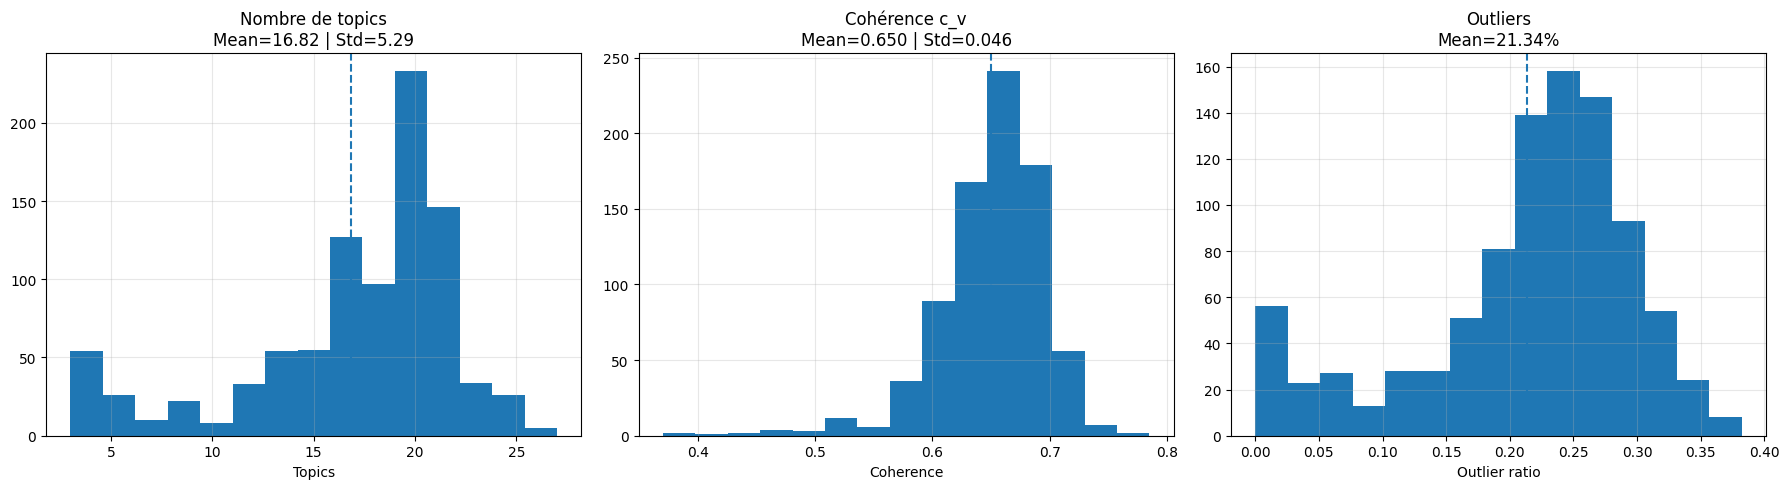

In [22]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import multiprocessing as mp

from joblib import Parallel, delayed
from tqdm import tqdm

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from gensim.models.coherencemodel import CoherenceModel
from sklearn.feature_extraction.text import CountVectorizer

# =========================================================
# ENVIRONNEMENT
# =========================================================

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

# =========================================================
# PARAMÈTRES
# =========================================================

n_rep = 1000               # commencer par 20/50 avant 500
sample_ratio = 0.5
replace = False

# True  -> stabilité globale pipeline
# False -> bootstrap pur (recommandé au début)
vary_umap_seed = False

# =========================================================
# DONNÉES
# =========================================================

n = len(docs_clean)
sample_size = int(n * sample_ratio)

# =========================================================
# CPU
# =========================================================

PHYSICAL_CORES = max(mp.cpu_count() // 2, 1)

# laisser un peu d'air au système
JOBLIB_JOBS = max(PHYSICAL_CORES - 1, 1)

print(f"Cœurs physiques estimés : {PHYSICAL_CORES}")
print(f"Joblib workers          : {JOBLIB_JOBS}")

# =========================================================
# BEST PARAMS
# =========================================================

best = study.best_params

print("\nBest params chargés")

# =========================================================
# FONCTION PRINCIPALE
# =========================================================

def run_replication(r):

    try:

        # -------------------------------------------------
        # ÉCHANTILLONNAGE
        # -------------------------------------------------

        rng = np.random.default_rng(seed=r)

        idx = rng.choice(
            n,
            size=sample_size,
            replace=replace
        )

        sub_docs = [docs_clean[i] for i in idx]
        sub_embeddings = embeddings[idx]
        sub_texts = [texts_filtered[i] for i in idx]

        # -------------------------------------------------
        # RANDOM STATE
        # -------------------------------------------------

        umap_seed = r if vary_umap_seed else 42

        # -------------------------------------------------
        # VECTORIZER
        # -------------------------------------------------

        vectorizer_model = CountVectorizer(
            ngram_range=(1, best["ngram_max"]),
            stop_words=FRENCH_STOPWORDS,
            min_df=best["min_df"],
            max_df=best["max_df"],
            tokenizer=tokenizer_fr,
            token_pattern=None,
            lowercase=True,
            analyzer="word"
        )

        # -------------------------------------------------
        # UMAP
        # -------------------------------------------------

        umap_model = UMAP(
            n_neighbors=best["umap_n_neighbors"],
            n_components=best["umap_n_components"],
            min_dist=best["umap_min_dist"],
            metric=best["umap_metric"],
            random_state=umap_seed
        )

        # -------------------------------------------------
        # HDBSCAN
        # -------------------------------------------------

        hdbscan_model = HDBSCAN(
            min_cluster_size=best["min_cluster_size"],
            min_samples=best["min_samples"],
            cluster_selection_epsilon=best["cluster_selection_epsilon"],
            metric="euclidean",
            prediction_data=True
        )

        # -------------------------------------------------
        # BERTopic
        # -------------------------------------------------

        topic_model = BERTopic(
            umap_model=umap_model,
            hdbscan_model=hdbscan_model,
            vectorizer_model=vectorizer_model,
            calculate_probabilities=False,
            low_memory=True,
            top_n_words=10,
            verbose=False
        )

        # -------------------------------------------------
        # FIT
        # -------------------------------------------------

        topics, _ = topic_model.fit_transform(
            sub_docs,
            sub_embeddings
        )

        # -------------------------------------------------
        # MÉTRIQUES
        # -------------------------------------------------

        unique_topics = set(topics)

        n_topics = len(unique_topics) - (
            1 if -1 in unique_topics else 0
        )

        outlier_ratio = (
            sum(t == -1 for t in topics)
            / len(topics)
        )

        # -------------------------------------------------
        # EXTRACTION TOPICS
        # -------------------------------------------------

        topic_words = []

        for t in unique_topics:

            if t == -1:
                continue

            topic = topic_model.get_topic(t)

            if topic is None:
                continue

            words = []

            for item in topic[:10]:

                if item is None:
                    continue

                word = item[0]

                if (
                    isinstance(word, str)
                    and len(word) > 1
                    and word in dictionary.token2id
                ):
                    words.append(word)

            # garder seulement les topics valides
            if len(words) >= 3:
                topic_words.append(words)

        # -------------------------------------------------
        # COHÉRENCE
        # -------------------------------------------------

        if len(topic_words) < 2:

            coherence = np.nan

        else:

            try:

                coherence = CoherenceModel(
                    topics=topic_words,
                    texts=sub_texts,
                    dictionary=dictionary,
                    coherence="c_v",
                    processes=1
                ).get_coherence()

            except Exception:

                coherence = np.nan

        # -------------------------------------------------
        # RETURN
        # -------------------------------------------------

        return {
            "replication": r,
            "n_topics": n_topics,
            "outlier_ratio": outlier_ratio,
            "coherence": coherence
        }

    except Exception as e:

        return {
            "replication": r,
            "error": str(e)
        }

# =========================================================
# EXÉCUTION PARALLÈLE
# =========================================================

print("\nDébut des réplications...")

results = Parallel(
    n_jobs=JOBLIB_JOBS,
    backend="loky",
    verbose=0
)(
    delayed(run_replication)(r)
    for r in tqdm(range(n_rep), desc="Réplications")
)

print("Réplications terminées")

# =========================================================
# ERREURS
# =========================================================

errors = [r for r in results if "error" in r]

if len(errors) > 0:

    print(f"\n{len(errors)} réplications en erreur")

    for e in errors[:5]:
        print(e)

# =========================================================
# DATAFRAME
# =========================================================

df_res = pd.DataFrame([
    r for r in results
    if "error" not in r
])

print("\nAperçu résultats")
print(df_res.head())

# =========================================================
# STATISTIQUES
# =========================================================

mean_topics = df_res["n_topics"].mean()
std_topics = df_res["n_topics"].std()

mean_coh = df_res["coherence"].mean()
std_coh = df_res["coherence"].std()

mean_out = df_res["outlier_ratio"].mean()
std_out = df_res["outlier_ratio"].std()

print("\n=================================================")
print("RÉSULTATS")
print("=================================================")

print(f"Topics moyens        : {mean_topics:.2f}")
print(f"Std topics           : {std_topics:.2f}")

print(f"\nCohérence moyenne    : {mean_coh:.4f}")
print(f"Std cohérence        : {std_coh:.4f}")

print(f"\nOutliers moyens      : {mean_out:.2%}")
print(f"Std outliers         : {std_out:.2%}")

# =========================================================
# VISUALISATIONS
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------------------------------------
# NOMBRE DE TOPICS
# ---------------------------------------------------------

axes[0].hist(
    df_res["n_topics"],
    bins=15
)

axes[0].axvline(
    mean_topics,
    linestyle="--"
)

axes[0].set_title(
    f"Nombre de topics\n"
    f"Mean={mean_topics:.2f} | Std={std_topics:.2f}"
)

axes[0].set_xlabel("Topics")

axes[0].grid(alpha=0.3)

# ---------------------------------------------------------
# COHÉRENCE
# ---------------------------------------------------------

axes[1].hist(
    df_res["coherence"].dropna(),
    bins=15
)

axes[1].axvline(
    mean_coh,
    linestyle="--"
)

axes[1].set_title(
    f"Cohérence c_v\n"
    f"Mean={mean_coh:.3f} | Std={std_coh:.3f}"
)

axes[1].set_xlabel("Coherence")

axes[1].grid(alpha=0.3)

# ---------------------------------------------------------
# OUTLIERS
# ---------------------------------------------------------

axes[2].hist(
    df_res["outlier_ratio"],
    bins=15
)

axes[2].axvline(
    mean_out,
    linestyle="--"
)

axes[2].set_title(
    f"Outliers\n"
    f"Mean={mean_out:.2%}"
)

axes[2].set_xlabel("Outlier ratio")

axes[2].grid(alpha=0.3)

# ---------------------------------------------------------
# FINAL
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    "bertopic_stability.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
from optuna.importance import get_param_importances
import pandas as pd

importance = get_param_importances(study)

importance_df = pd.DataFrame({
    "paramètre": importance.keys(),
    "importance": importance.values()
}).sort_values("importance", ascending=False)

print(importance_df)

                   paramètre  importance
0           umap_n_neighbors    0.226804
1          umap_n_components    0.157933
2              umap_min_dist    0.152339
3   cluster_selection_method    0.130127
4                     max_df    0.129451
5                     min_df    0.067183
6           min_cluster_size    0.048885
7                  ngram_max    0.040148
8  cluster_selection_epsilon    0.037763
9                umap_metric    0.009367


In [24]:
from optuna.visualization import plot_param_importances

fig = plot_param_importances(study)
fig.show()

In [25]:
from optuna.visualization import plot_slice

fig = plot_slice(study)
fig.show()

In [26]:
from optuna.visualization import plot_contour

fig = plot_contour(
    study,
    params=["umap_n_neighbors", "min_cluster_size"]
)
fig.show()

In [27]:
trials_df = study.trials_dataframe()

print(trials_df.columns)  
cols = [
    "value",
    "params_umap_n_neighbors",
    "params_min_cluster_size",
    "params_min_samples",
    "user_attrs_n_topics",
    "user_attrs_outlier_ratio",
    "user_attrs_coherence"
]

analysis_df = trials_df[cols]

print(analysis_df.corr(numeric_only=True))

Index(['number', 'value', 'datetime_start', 'datetime_complete', 'duration',
       'params_cluster_selection_epsilon', 'params_cluster_selection_method',
       'params_max_df', 'params_min_cluster_size', 'params_min_df',
       'params_min_samples', 'params_ngram_max', 'params_umap_metric',
       'params_umap_min_dist', 'params_umap_n_components',
       'params_umap_n_neighbors', 'user_attrs_coherence',
       'user_attrs_max_topic_pct', 'user_attrs_n_topics',
       'user_attrs_outlier_ratio', 'state'],
      dtype='object')
                             value  params_umap_n_neighbors  \
value                     1.000000                -0.555167   
params_umap_n_neighbors  -0.555167                 1.000000   
params_min_cluster_size   0.246503                -0.257304   
params_min_samples        0.122479                -0.239217   
user_attrs_n_topics      -0.579004                 0.217928   
user_attrs_outlier_ratio -0.359940                 0.377411   
user_attrs_coherence   

  seed1 vs seed2       → Jaccard = 0.4252
  seed1 vs seed3       → Jaccard = 0.2149
  seed1 vs seed4       → Jaccard = 0.2180
  seed1 vs seed5       → Jaccard = 0.1574
  seed2 vs seed3       → Jaccard = 0.2235
  seed2 vs seed4       → Jaccard = 0.2449
  seed2 vs seed5       → Jaccard = 0.1688
  seed3 vs seed4       → Jaccard = 0.3159
  seed3 vs seed5       → Jaccard = 0.1993
  seed4 vs seed5       → Jaccard = 0.1881

📊 JACCARD STABILITY — PARTITION
Paires comparées : 10
Moyenne          : 0.2356
Std              : 0.0758
Min              : 0.1574
Max              : 0.4252


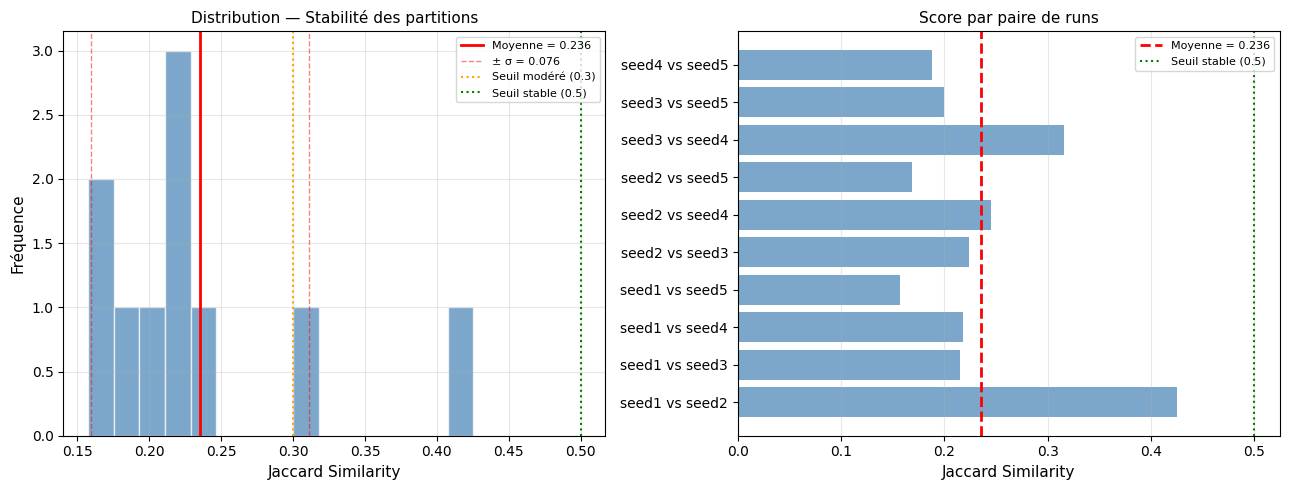

In [33]:
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# JACCARD SUR PARTITION (Ben-Hur et al., 2002)
# =========================================================

def jaccard_similarity(labels1, labels2):
    same_cluster_1 = set()
    same_cluster_2 = set()
    n = len(labels1)

    for i in range(n):
        if labels1[i] == -1:
            continue
        for j in range(i + 1, n):
            if labels1[j] == -1:
                continue
            if labels1[i] == labels1[j]:
                same_cluster_1.add((i, j))
            if labels2[i] == labels2[j]:
                same_cluster_2.add((i, j))

    intersection = len(same_cluster_1 & same_cluster_2)
    union        = len(same_cluster_1 | same_cluster_2)

    return intersection / union if union > 0 else np.nan

# =========================================================
# TOUTES LES PAIRES DE RUNS
# =========================================================

scores      = []
paire_labels = []

for (i, t1), (j, t2) in combinations(enumerate(all_topics), 2):
    jac = jaccard_similarity(t1, t2)
    if not np.isnan(jac):
        scores.append(jac)
        paire_labels.append(f"seed{i+1} vs seed{j+1}")
        print(f"  {paire_labels[-1]:20} → Jaccard = {jac:.4f}")

print(f"\n📊 JACCARD STABILITY — PARTITION")
print(f"Paires comparées : {len(scores)}")
print(f"Moyenne          : {np.mean(scores):.4f}")
print(f"Std              : {np.std(scores):.4f}")
print(f"Min              : {np.min(scores):.4f}")
print(f"Max              : {np.max(scores):.4f}")

# =========================================================
# VISUALISATION
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Distribution
ax = axes[0]
ax.hist(scores, bins=15, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.mean(scores), color='red', linewidth=2,
           label=f'Moyenne = {np.mean(scores):.3f}')
ax.axvline(np.mean(scores) - np.std(scores), color='red',
           linewidth=1, linestyle='--', alpha=0.5)
ax.axvline(np.mean(scores) + np.std(scores), color='red',
           linewidth=1, linestyle='--', alpha=0.5,
           label=f'± σ = {np.std(scores):.3f}')
ax.axvline(0.3, color='orange', linewidth=1.5,
           linestyle=':', label='Seuil modéré (0.3)')
ax.axvline(0.5, color='green', linewidth=1.5,
           linestyle=':', label='Seuil stable (0.5)')
ax.set_xlabel("Jaccard Similarity", fontsize=11)
ax.set_ylabel("Fréquence", fontsize=11)
ax.set_title("Distribution — Stabilité des partitions", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Score par paire
ax = axes[1]
ax.barh(paire_labels, scores, color='steelblue', alpha=0.7)
ax.axvline(np.mean(scores), color='red', linewidth=2,
           linestyle='--', label=f'Moyenne = {np.mean(scores):.3f}')
ax.axvline(0.5, color='green', linewidth=1.5,
           linestyle=':', label='Seuil stable (0.5)')
ax.set_xlabel("Jaccard Similarity", fontsize=11)
ax.set_title("Score par paire de runs", fontsize=11)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig("jaccard_partition_stability.png", dpi=300, bbox_inches='tight')
plt.show()

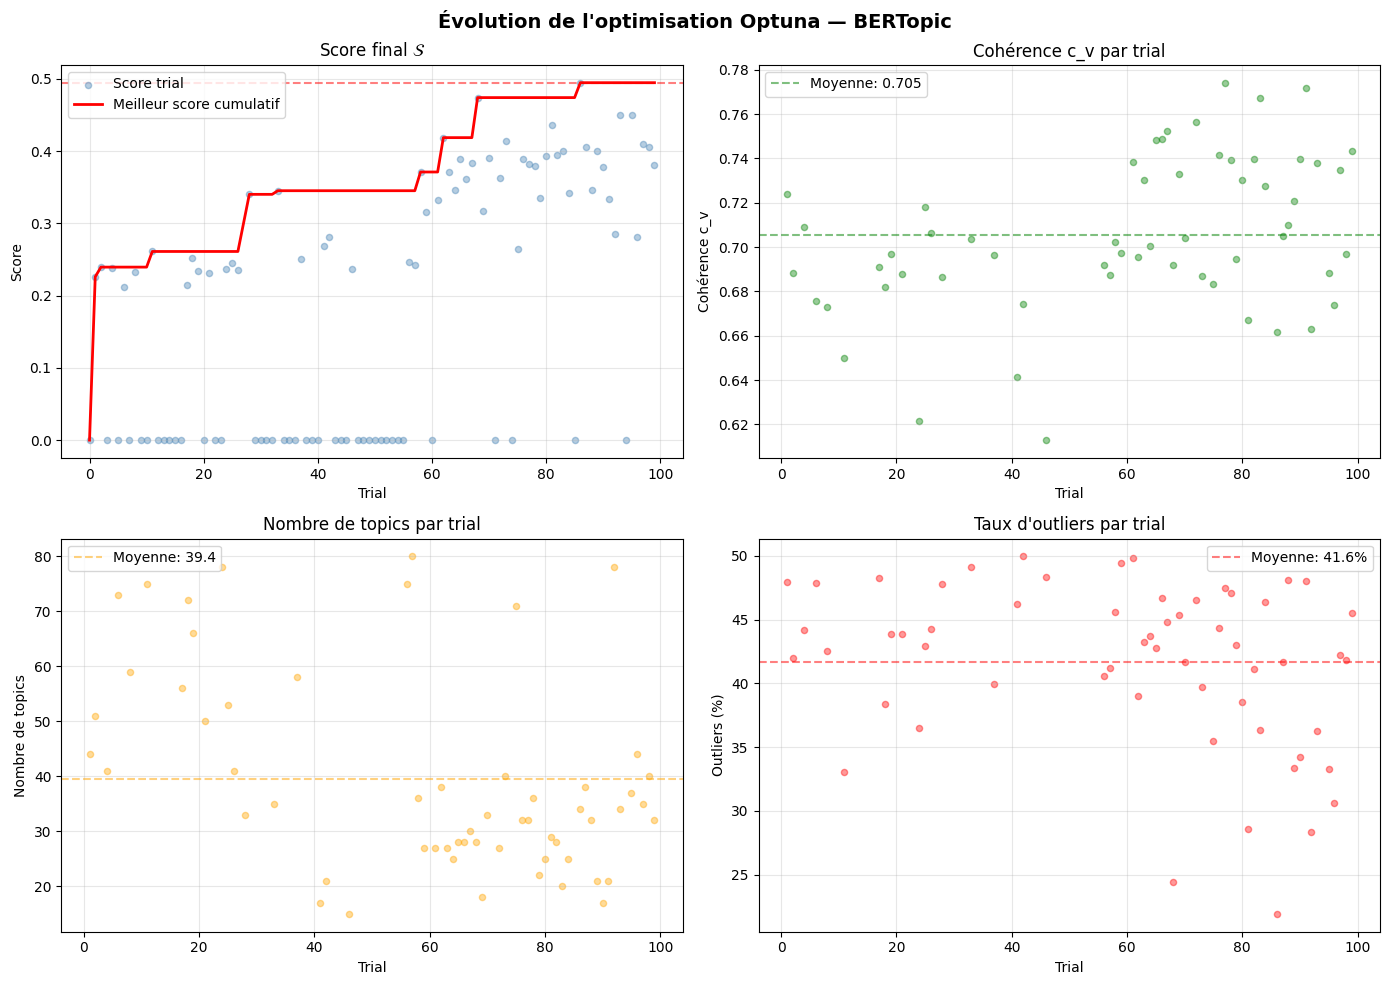

✅ Figure sauvegardée : optuna_evolution.png


In [35]:
import matplotlib.pyplot as plt
import numpy as np

# Extraire les données de l'étude
trials      = study.trials
trial_nums  = [t.number for t in trials if t.value is not None]
scores      = [t.value  for t in trials if t.value is not None]
best_scores = np.maximum.accumulate(scores)  # meilleur score cumulatif

# Récupérer les attributs
n_topics_list    = [t.user_attrs.get("n_topics", None)      for t in trials if t.value is not None]
outlier_list     = [t.user_attrs.get("outlier_ratio", None) for t in trials if t.value is not None]
coherence_list   = [t.user_attrs.get("coherence", None)     for t in trials if t.value is not None]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Évolution de l'optimisation Optuna — BERTopic", fontsize=14, fontweight='bold')

# -------- Plot 1 : Score final --------
ax = axes[0, 0]
ax.scatter(trial_nums, scores, alpha=0.4, color='steelblue', s=20, label='Score trial')
ax.plot(trial_nums, best_scores, color='red', linewidth=2, label='Meilleur score cumulatif')
ax.axhline(y=study.best_value, color='red', linestyle='--', alpha=0.5)
ax.set_title("Score final $\\mathcal{S}$")
ax.set_xlabel("Trial")
ax.set_ylabel("Score")
ax.legend()
ax.grid(alpha=0.3)

# -------- Plot 2 : Cohérence --------
ax = axes[0, 1]
coh_valid = [(n, c) for n, c in zip(trial_nums, coherence_list) if c is not None]
if coh_valid:
    ns, cs = zip(*coh_valid)
    ax.scatter(ns, cs, alpha=0.4, color='green', s=20)
    ax.axhline(y=np.mean(cs), color='green', linestyle='--', alpha=0.5, label=f'Moyenne: {np.mean(cs):.3f}')
ax.set_title("Cohérence c_v par trial")
ax.set_xlabel("Trial")
ax.set_ylabel("Cohérence c_v")
ax.legend()
ax.grid(alpha=0.3)

# -------- Plot 3 : Nombre de topics --------
ax = axes[1, 0]
top_valid = [(n, t) for n, t in zip(trial_nums, n_topics_list) if t is not None]
if top_valid:
    ns, ts = zip(*top_valid)
    ax.scatter(ns, ts, alpha=0.4, color='orange', s=20)
    ax.axhline(y=np.mean(ts), color='orange', linestyle='--', alpha=0.5, label=f'Moyenne: {np.mean(ts):.1f}')
ax.set_title("Nombre de topics par trial")
ax.set_xlabel("Trial")
ax.set_ylabel("Nombre de topics")
ax.legend()
ax.grid(alpha=0.3)

# -------- Plot 4 : Taux d'outliers --------
ax = axes[1, 1]
out_valid = [(n, o) for n, o in zip(trial_nums, outlier_list) if o is not None]
if out_valid:
    ns, os_ = zip(*out_valid)
    ax.scatter(ns, [o * 100 for o in os_], alpha=0.4, color='red', s=20)
    ax.axhline(y=np.mean(os_) * 100, color='red', linestyle='--', alpha=0.5,
               label=f'Moyenne: {np.mean(os_)*100:.1f}%')
ax.set_title("Taux d'outliers par trial")
ax.set_xlabel("Trial")
ax.set_ylabel("Outliers (%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("optuna_evolution.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Figure sauvegardée : optuna_evolution.png")

# Labelisation de thématiques automatiques 


In [36]:
!pip install openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 1.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [openai]2m2/3 [openai]


In [40]:
 OPENAI_API_KEY="ta_cle_api"

In [ ]:
from openai import OpenAI
import pandas as pd
#os.environ["OPENAI_API_KEY"] = "mettre votre clé openAI "

client = OpenAI()

bertopic_model_fixed = BERTopic.load("bertopic_model_fixed")

# =========================================================
# FONCTION LABEL OPENAI
# =========================================================

def generate_label(topic_words, docs):

    words_str = ", ".join(topic_words)

    docs_str = "\n".join(docs[:3])

    prompt = f"""
Tu es un expert en analyse thématique académique.

Voici les mots-clés d’un topic BERTopic :

{words_str}

Voici quelques documents représentatifs :

{docs_str}

Donne :
- un label thématique court
- en français
- académique
- maximum 6 mots
- sans guillemets
"""

    response = client.chat.completions.create(
        model="gpt-5-mini",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ]
        
    )

    return response.choices[0].message.content.strip()

# =========================================================
# GENERATION DES LABELS
# =========================================================

topic_labels = {}

for topic_id in bertopic_model_fixed.get_topics():

    if topic_id == -1:
        continue

    # top mots
    topic_words = [
        word
        for word, _ in bertopic_model_fixed.get_topic(topic_id)[:25]
    ]

    # docs représentatifs
    docs = bertopic_model_fixed.get_representative_docs(topic_id)

    # génération label
    label = generate_label(topic_words, docs)

    topic_labels[topic_id] = label

    print(f"Topic {topic_id} → {label}")

Topic 0 → Chaleur, sécheresse et instabilité orageuse
Topic 1 → Sécheresse, eau, rendements et prix
Topic 2 → Présidence, partis et négociations gouvernementales
Topic 3 → Ouragans tropicaux et risques côtiers
Topic 4 → Interventions d'urgence des pompiers en inondations
Topic 5 → Gestion communale de l'eau et inondations
Topic 6 → Incendies forestiers en Californie
Topic 7 → Accidentologie et sécurité aérienne
Topic 8 → Vécu collectif des habitants urbains
Topic 9 → Impacts et réponses au typhon Haiyan
Topic 10 → Famine, sécheresse et déplacements en Somalie
Topic 11 → Incendies forestiers en Nouvelle‑Galles‑du‑Sud
Topic 12 → Cyclones et vulnérabilité des populations côtières
Topic 13 → Fiabilité et perturbations du service ferroviaire
Topic 14 → Inondations, glissements et mortalité
Topic 15 → Intempéries extrêmes et sécurité des festivals
Topic 16 → COVID-19 : épidémiologie, mortalité et interventions sanitaires
Topic 17 → Impacts socio-environnementaux des typhons à Tokyo
Topic 18 

In [53]:
import pandas as pd
import random

# =========================================================
# PARAMÈTRES
# =========================================================

N_ARTICLES = 4   # nombre d’articles par topic

# =========================================================
# DATAFRAME DES DOCUMENTS + TOPICS
# =========================================================

df_topics = pd.DataFrame({
    "document": docs_clean,
    "topic": topics
})

# enlever les outliers
df_topics = df_topics[df_topics["topic"] != -1].copy()

# =========================================================
# LABELS DES TOPICS
# =========================================================

topic_labels = {
    0: "Chaleur, sécheresse et instabilité orageuse",
    1: "Sécheresse, eau, rendements et prix",
    2: "Présidence, partis et négociations gouvernementales",
    3: "Ouragans tropicaux et risques côtiers",
    4: "Interventions d'urgence des pompiers en inondations",
    5: "Gestion communale de l'eau et inondations",
    6: "Incendies forestiers en Californie",
    7: "Accidentologie et sécurité aérienne",
    8: "Vécu collectif des habitants urbains",
    9: "Impacts et réponses au typhon Haiyan",
    10: "Famine, sécheresse et déplacements en Somalie",
    11: "Incendies forestiers en Nouvelle-Galles-du-Sud",
    12: "Cyclones et vulnérabilité des populations côtières",
    13: "Fiabilité et perturbations du service ferroviaire",
    14: "Inondations, glissements et mortalité",
    15: "Intempéries extrêmes et sécurité des festivals",
    16: "COVID-19 : épidémiologie, mortalité et interventions sanitaires",
    17: "Impacts socio-environnementaux des typhons à Tokyo",
    18: "Impacts hydrométéorologiques et socio-économiques des typhons",
    19: "Inondations, mortalité et aide humanitaire",
    20: "Crise humanitaire des inondations au Pakistan",
    21: "Accidents, victimes et procédures judiciaires",
    22: "Interventions des pompiers lors d'intempéries",
    23: "Inondations, impacts humains et réponses publiques",
    24: "Catastrophes naturelles et gestion russe",
    25: "Fréquentation touristique des musées et attractions",
    26: "Coûts assurantiels des catastrophes naturelles",
    27: "Risques hydrogéologiques en Indonésie",
    28: "Revitalisation commerciale des centres-villes",
    29: "Fermetures et sécurisation des parcs",
    30: "Tempêtes hivernales : vents, submersions et perturbations",
    31: "Gestion des niveaux d'eau et barrages",
    32: "Incendies forestiers et protection civile portugaise",
    33: "Vents violents et cyclones tropicaux"
}

# =========================================================
# EXTRACTION ARTICLES PAR TOPIC
# =========================================================

rows = []

for topic_id in sorted(df_topics["topic"].unique()):

    subset = df_topics[df_topics["topic"] == topic_id]

    # prendre des articles aléatoires
    sample_docs = subset.sample(
        n=min(N_ARTICLES, len(subset)),
        random_state=42
    )

    for i, row in enumerate(sample_docs.itertuples(), start=1):

        rows.append({
            "topic_id": topic_id,
            "label": topic_labels.get(topic_id, "NA"),
            "article_ref": f"A{i}",
            "texte_article": row.document[:1500]  # limite taille Excel
        })

# =========================================================
# DATAFRAME FINAL
# =========================================================

df_export = pd.DataFrame(rows)

# =========================================================
# EXPORT EXCEL
# =========================================================

output_file = "topics_articles_reference.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    df_export.to_excel(writer, index=False, sheet_name="topics")

print(f" Fichier exporté : {output_file}")

print(df_export.head())

 Fichier exporté : topics_articles_reference.xlsx
   topic_id                                        label article_ref  \
0         0  Chaleur, sécheresse et instabilité orageuse          A1   
1         0  Chaleur, sécheresse et instabilité orageuse          A2   
2         0  Chaleur, sécheresse et instabilité orageuse          A3   
3         0  Chaleur, sécheresse et instabilité orageuse          A4   
4         1          Sécheresse, eau, rendements et prix          A1   

                                       texte_article  
0  cyberattaque mondiale massive milliards_dollar...  
1  cours terme blé début euros_tonne marché europ...  
2  lumière événements arrivée ouragan ndlr irai c...  
3  bancassureur kbc bénéfice_net milliard_euros c...  
4  station_épuration possible eau_salée eau_potab...  


In [55]:
# =========================================================
# EXTRAIRE LES 10 PREMIERS MOTS DE CHAQUE TOPIC
# =========================================================

topic_words = []

for topic_id in sorted(bertopic_model_fixed.get_topics().keys()):

    # ignorer les outliers
    if topic_id == -1:
        continue

    # récupérer les mots du topic
    words = bertopic_model_fixed.get_topic(topic_id)

    # garder uniquement les 10 premiers mots
    top_10 = [word for word, score in words[:10]]

    topic_words.append({
        "topic_id": topic_id,
        "top_words": ", ".join(top_10)
    })

# =========================================================
# DATAFRAME
# =========================================================

import pandas as pd

df_topic_words = pd.DataFrame(topic_words)

# affichage
print(df_topic_words)

# =========================================================
# EXPORT EXCEL
# =========================================================

df_topic_words.to_excel(
    "top_10_words_topics.xlsx",
    index=False
)

print("Fichier exporté : top_10_words_topics.xlsx")

    topic_id                                          top_words
0          0  degrs, tempratures, pays, averses, ouest, vent...
1          1  eau, scheresse, agriculteurs, anne, production...
2          2  prsident, pays, politique, accord, gouvernemen...
3          3  ouragan, nhc, hati, ouragans, temptetropicale,...
4          4  pompiers, caves, eau, belga, inondations, rue,...
5          5  communes, eau, commune, swde, projet, travaux,...
6          6  californie, incendies, incendie, pompiers, feu...
7          7  avion, aroport, vol, passagers, vols, compagni...
8          8  personnes, enfants, ans, ville, eau, habitants...
9          9  philippines, typhon, manille, personnes, archi...
10        10  somalie, famine, pays, mozambique, rfugis, mil...
11        11  incendies, incendie, hectares, pompiers, feux,...
12        12  cyclone, bangladesh, archipel, le, personnes, ...
13        13  trains, ligne, train, sncb, bruxelles, lignes,...
14        14  personnes, victimes, morts

# BERTopic Dynamique.

             pub_date  annee_index
0 2008-06-02 18:10:00         2008
1 2008-05-18 12:54:00         2008
2 2008-11-17 10:04:00         2008
3 2008-06-23 14:49:00         2008
4 2008-09-30 21:41:00         2008
        id            pub_date      feed  category keyword signature  \
0  5278693 2008-06-02 18:10:00  RTBFINFO  BELGIQUE     NaN     Belga   
1  5238473 2008-05-18 12:54:00  RTBFINFO     MONDE     NaN     Belga   
2  5215253 2008-11-17 10:04:00  RTBFINFO     MONDE     NaN      RTBF   
3  5289293 2008-06-23 14:49:00  RTBFINFO     MONDE     NaN      RTBF   
4  5196373 2008-09-30 21:41:00  RTBFINFO  BELGIQUE     NaN      RTBF   

                                               title  \
0  Intempéries: problèmes de trafic à Namur, Char...   
1  Birmanie: De Crem aux préparatifs de l'envoi d...   
2  Incendies : le vent tombe dans le sud de la Ca...   
3  Philippines: le bilan du typhon alourdi par un...   
4  Un  député dénonce les conditions de détention...   

                    

3it [00:01,  1.72it/s]


Jensen-Shannon moyen : 0.1369

===== SPLIT 4 =====


4it [00:02,  1.95it/s]


Jensen-Shannon moyen : 0.1271

===== SPLIT 5 =====


...

Jensen-Shannon moyen : 0.1366

===== SPLIT 12 =====


12it [00:05,  2.32it/s]


Jensen-Shannon moyen : 0.1440

===== SPLIT 13 =====


13it [00:05,  2.32it/s]

Jensen-Shannon moyen : 0.1648


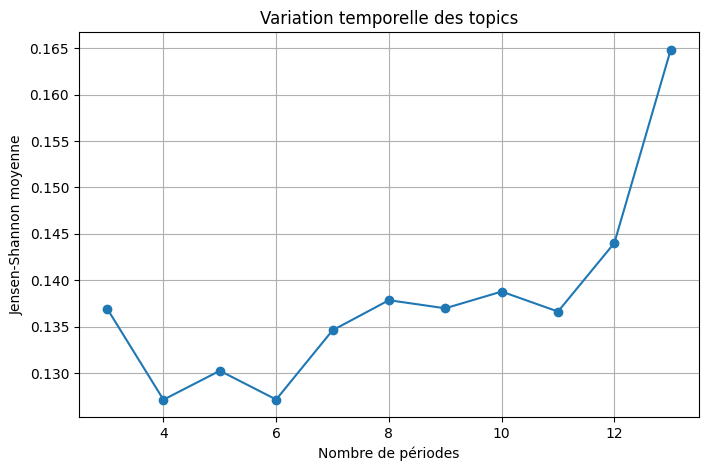

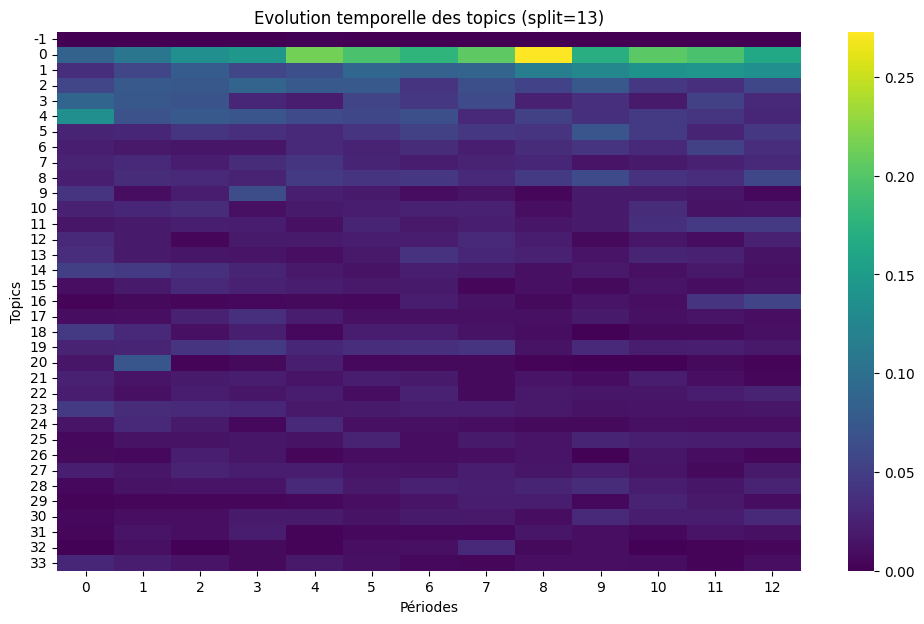

    split   js_mean
1       4  0.127121
3       6  0.127142
2       5  0.130243
4       7  0.134601
8      11  0.136622
0       3  0.136949
6       9  0.136974
5       8  0.137847
7      10  0.138776
9      12  0.144008
10     13  0.164837

✅ Export terminé


In [31]:
# =========================================================
# ANALYSE TEMPORELLE BERTopic
# Jensen-Shannon + UMass
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import jensenshannon


bertopic_model_fixed = BERTopic.load("bertopic_model_fixed")

# =========================================================
# CONVERSION DATE
# =========================================================

df_select_trie2["pub_date"] = pd.to_datetime(
    df_select_trie2["pub_date"]
)

# =========================================================
# VARIABLE TEMPORELLE
# =========================================================

df_select_trie2["annee_index"] = (
    df_select_trie2["pub_date"].dt.year
)

print(
    df_select_trie2[["pub_date", "annee_index"]].head()
)

df_select_trie2 = df_select_trie2.reset_index(drop=True)

# vérifier
print(df_select_trie2.head())


   

# =========================================================
# 2. MATRICE TOPICS x TEMPS
# =========================================================

def build_topic_time_matrix(topics_over_time):

    pivot = topics_over_time.pivot_table(
        index="Topic",
        columns="Timestamp",
        values="Frequency",
        fill_value=0
    )

    # normalisation
    pivot = pivot.div(
        pivot.sum(axis=0),
        axis=1
    )

    return pivot

# =========================================================
# 3. JENSEN-SHANNON
# =========================================================

def compute_js_divergence(matrix):

    js_scores = []

    cols = matrix.columns.tolist()

    for i in range(len(cols)-1):

        p = matrix[cols[i]].values
        q = matrix[cols[i+1]].values

        js = jensenshannon(p, q)

        js_scores.append(js)

    return np.mean(js_scores), js_scores

# =========================================================
# 4. ANALYSE GRANULARITÉ TEMPORELLE
# =========================================================

def analyser_granularite_bertopic(
    model,
    docs,
    dates,
    texts_filtered,
    splits=[3,4,5,6,8,10,12]
):

    results = {}

    for n_splits in splits:

        print(f"\n===== SPLIT {n_splits} =====")

        # -------------------------------------------------
        # découpage temporel
        # -------------------------------------------------

        periods = pd.qcut(
            dates.rank(method="first"),
            q=n_splits,
            labels=False
        )

        # -------------------------------------------------
        # topics over time
        # -------------------------------------------------

        topics_over_time = model.topics_over_time(
            docs,
            periods,
            nr_bins=None
        )

        # -------------------------------------------------
        # matrice topics x temps
        # -------------------------------------------------

        matrix = build_topic_time_matrix(
            topics_over_time
        )

        # -------------------------------------------------
        # JENSEN-SHANNON
        # -------------------------------------------------

        js_mean, js_scores = compute_js_divergence(
            matrix
        )
        # -------------------------------------------------
        # stockage
        # -------------------------------------------------

        results[n_splits] = {
            "topics_over_time": topics_over_time,
            "matrix": matrix,
            "js_mean": js_mean,
            "js_scores": js_scores,
        }

        print(f"Jensen-Shannon moyen : {js_mean:.4f}")

    return results

# =========================================================
# 5. VISUALISATION JSD
# =========================================================

def visualiser_js(results):

    splits = list(results.keys())

    js_scores = [
        results[s]["js_mean"]
        for s in splits
    ]

    plt.figure(figsize=(8,5))

    plt.plot(
        splits,
        js_scores,
        marker='o'
    )

    plt.xlabel("Nombre de périodes")
    plt.ylabel("Jensen-Shannon moyenne")

    plt.title(
        "Variation temporelle des topics"
    )

    plt.grid(True)

    plt.show()

# =========================================================
# 6. VISUALISATION HEATMAP
# =========================================================

def visualiser_heatmap(results, split):

    matrix = results[split]["matrix"]

    plt.figure(figsize=(12,7))

    sns.heatmap(
        matrix,
        cmap="viridis"
    )

    plt.title(
        f"Evolution temporelle des topics (split={split})"
    )

    plt.xlabel("Périodes")
    plt.ylabel("Topics")

    plt.show()

# =========================================================
# 7. TABLEAU RÉSUMÉ
# =========================================================

def tableau_resultats(results):

    rows = []

    for split in results:

        rows.append({
            "split": split,
            "js_mean": results[split]["js_mean"]
        })

    df_results = pd.DataFrame(rows)

    return df_results.sort_values(
        by="js_mean"
    )

# =========================================================
# 8. UTILISATION
# =========================================================

results = analyser_granularite_bertopic(
    model=bertopic_model_fixed,
    docs=docs_clean,
    dates=df_select_trie2["annee_index"],
    texts_filtered=texts_filtered,
    splits=[3,4,5,6,7,8,9,10,11,12,13]
)

# =========================================================
# VISUALISATIONS
# =========================================================

visualiser_js(results)

visualiser_heatmap(results, split=13)

# =========================================================
# TABLEAU FINAL
# =========================================================

df_eval = tableau_resultats(results)

print(df_eval)

df_eval.to_excel(
    "evaluation_temporelle_bertopic.xlsx",
    index=False
)

print("\n✅ Export terminé")

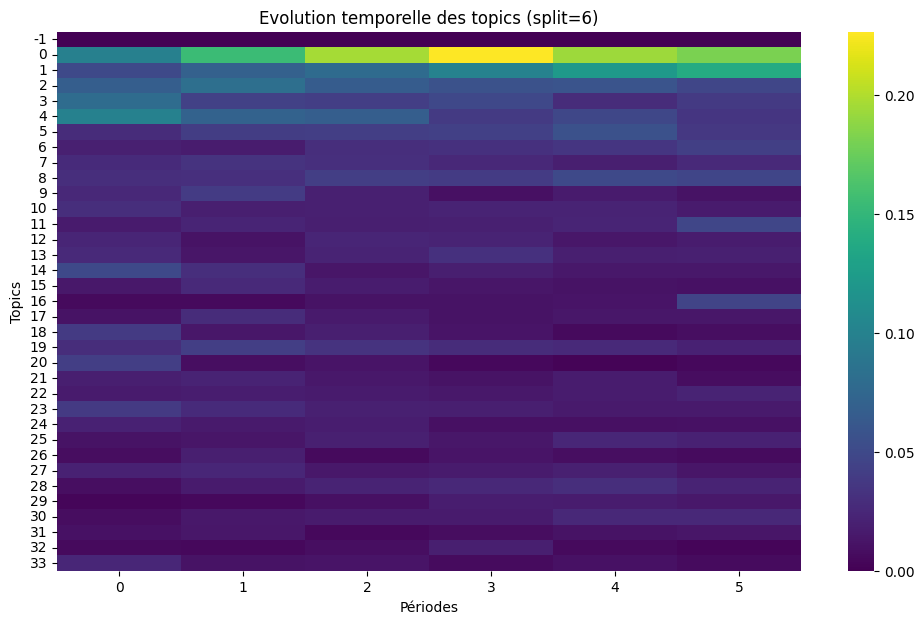

In [32]:
visualiser_heatmap(results, split=6)

## Construction du modèle finale. 

In [52]:
# =========================================================
# PREPARATION TEMPORELLE — 8 périodes strictement égales
# =========================================================

df_select_trie2 = df_select_trie2.reset_index(drop=True)
df_select_trie2["pub_date"] = pd.to_datetime(df_select_trie2["pub_date"])

# Trie par date
df_select_trie2 = df_select_trie2.sort_values("pub_date").reset_index(drop=True)

# Coupe sur le rang → effectifs strictement égaux
bins = pd.qcut(df_select_trie2.index, q=8, labels=False)
df_select_trie2["periode"] = bins

# Deux séries : une pour BERTopic (année début parseable), une pour affichage
periode_info = df_select_trie2.groupby("periode")["pub_date"].agg(
    annee_debut=lambda x: x.dt.year.min(),
    annee_fin=lambda x: x.dt.year.max()
)

# Timestamps pour BERTopic → année de début uniquement (parseable)
year_start = periode_info["annee_debut"].astype(str)
timestamps = df_select_trie2["periode"].map(year_start)

# Labels lisibles pour la visualisation → "2008_2012"
year_labels = periode_info.apply(
    lambda row: f"{row['annee_debut']}_{row['annee_fin']}", axis=1
)
label_map = df_select_trie2["periode"].map(year_labels)

# Vérification
print("Effectifs par période :")
print(label_map.value_counts().sort_index())

# Réaligne docs_clean
docs_clean = [docs_clean[i] for i in df_select_trie2.index]

# =========================================================
# TOPICS OVER TIME
# =========================================================

topics_over_time = bertopic_model_fixed.topics_over_time(
    docs_clean,
    timestamps,          # ← années simples pour BERTopic
    global_tuning=True,
    evolution_tuning=True
)

# Remplace les timestamps dans le résultat par les labels lisibles
timestamp_to_label = dict(zip(
    pd.to_datetime(year_start, format="%Y"),
    year_labels
))
topics_over_time["Timestamp"] = topics_over_time["Timestamp"].map(timestamp_to_label)

print(topics_over_time.head())

Effectifs par période :
periode
2008_2010    1120
2010_2013    1120
2013_2015    1119
2015_2016    1120
2016_2017    1120
2017_2018    1119
2018_2019    1120
2019_2021    1120
Name: count, dtype: int64


8it [00:03,  2.01it/s]

   Topic                                            Words  Frequency  \
0      0           degrs, pays, tempratures, belga, temps        109   
1      1            bl, plantes, crales, prix, production         45   
2      2  politique, prsident, gouvernement, pays, accord         66   
3      3     ouragan, hati, mexique, temptetropicale, nhc         92   
4      4                 pompiers, caves, belga, eau, gfr        126   

   Timestamp  
0  2008_2010  
1  2008_2010  
2  2008_2010  
3  2008_2010  
4  2008_2010  


## visualisation BERT Dynamic finale. 

In [53]:
# =========================================================
# VISUALISATION
# =========================================================

fig = bertopic_model_fixed.visualize_topics_over_time(
    topics_over_time,
    top_n_topics=15
)

fig.show()

In [54]:
topics_over_time.to_excel(
    "bertopic_topics_over_time.xlsx",
    index=False
)

print("✅ Export topics_over_time terminé")

✅ Export topics_over_time terminé


In [55]:
# =========================================================
# TAUX DE RENOUVELLEMENT (Tr)
# =========================================================

def compute_taux_renouvellement(topics_over_time, top_n=25):
    """
    Calcule le taux de renouvellement lexical entre périodes consécutives
    pour chaque topic issu de topics_over_time (BERTopic).
    
    Tr(k, t→t+1) = |W(t+1) \ W(t)| / n
    """
    results = []

    # Periods triées
    timestamps = sorted(topics_over_time["Timestamp"].unique())
    topics    = sorted(topics_over_time["Topic"].unique())

    for topic in topics:
        df_topic = topics_over_time[topics_over_time["Topic"] == topic].copy()
        df_topic = df_topic.set_index("Timestamp")

        for i in range(len(timestamps) - 1):
            t0 = timestamps[i]
            t1 = timestamps[i + 1]

            if t0 not in df_topic.index or t1 not in df_topic.index:
                continue

            # Extrait les top_n mots de chaque période
            def parse_words(row):
                return set(
                    w.strip()
                    for w in row["Words"].split(",")[:top_n]
                )

            W_t0 = parse_words(df_topic.loc[t0])
            W_t1 = parse_words(df_topic.loc[t1])

            # Nouveaux entrants : présents en t+1 mais absents en t
            nouveaux   = W_t1 - W_t0
            # Mots sortants : présents en t mais absents en t+1
            sortants   = W_t0 - W_t1
            # Mots stables
            stables    = W_t0 & W_t1

            Tr = len(nouveaux) / top_n

            results.append({
                "Topic"      : topic,
                "Periode"    : f"{t0} → {t1}",
                "Tr"         : round(Tr, 3),
                "Tr_%"       : round(Tr * 100, 1),
                "Nouveaux"   : sorted(nouveaux),
                "Sortants"   : sorted(sortants),
                "Stables"    : sorted(stables),
                "N_nouveaux" : len(nouveaux),
                "N_stables"  : len(stables),
                "Alerte"     : Tr > 0.25   # seuil défini dans ta méthodologie
            })

    return pd.DataFrame(results)


# =========================================================
# APPLICATION
# =========================================================

df_tr = compute_taux_renouvellement(topics_over_time, top_n=25)

# Vue globale
print(df_tr[["Topic", "Periode", "Tr_%", "N_nouveaux", "N_stables", "Alerte"]])

# Topics avec rupture discursive (Tr > 25%)
print("\n⚠️ Alertes — ruptures discursives :")
print(df_tr[df_tr["Alerte"]][["Topic", "Periode", "Tr_%", "Nouveaux"]])

# Tr moyen par topic (stabilité générale)
print("\nTr moyen par topic :")
print(df_tr.groupby("Topic")["Tr_%"].mean().sort_values(ascending=False))

     Topic                Periode  Tr_%  N_nouveaux  N_stables  Alerte
0        0  2008_2010 → 2010_2013   8.0           2          3   False
1        0  2010_2013 → 2013_2015   4.0           1          4   False
2        0  2013_2015 → 2015_2016   4.0           1          4   False
3        0  2015_2016 → 2016_2017   0.0           0          5   False
4        0  2016_2017 → 2017_2018   8.0           2          3   False
..     ...                    ...   ...         ...        ...     ...
233     33  2013_2015 → 2015_2016  12.0           3          2   False
234     33  2015_2016 → 2016_2017  20.0           5          0   False
235     33  2016_2017 → 2017_2018  20.0           5          0   False
236     33  2017_2018 → 2018_2019   8.0           2          3   False
237     33  2018_2019 → 2019_2021  20.0           5          0   False

[238 rows x 6 columns]

⚠️ Alertes — ruptures discursives :
Empty DataFrame
Columns: [Topic, Periode, Tr_%, Nouveaux]
Index: []

Tr moyen par topic

# Labelisation des topics par périodes Dynamiques 

In [ ]:
from openai import OpenAI
import pandas as pd
import os

# os.environ["OPENAI_API_KEY"] = "mettre votre propre clé"

client = OpenAI()

# =========================================================
# FONCTION LABEL OPENAI — VERSION DYNAMIQUE
# =========================================================

def generate_label_dynamic(topic_id, periode, topic_words, docs):

    words_str = ", ".join(topic_words)

    # Normalise et aplatit docs en liste de strings
    if isinstance(docs, dict):
        docs_list = list(docs.values())
    else:
        docs_list = list(docs)

    # Aplatit les listes imbriquées [[doc1], [doc2]] → [doc1, doc2]
    flat_docs = []
    for item in docs_list:
        if isinstance(item, list):
            flat_docs.extend([str(d) for d in item])
        else:
            flat_docs.append(str(item))

    docs_str = "\n".join(flat_docs[:3])

    prompt = f"""
Tu es un expert en analyse thématique académique.

Voici les mots-clés d'un topic BERTopic pour la période {periode} :

{words_str}

Voici quelques documents représentatifs :

{docs_str}

Donne :
- un label thématique court
- en français
- académique
- maximum 6 mots
- sans guillemets
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content.strip()


# =========================================================
# GENERATION DES LABELS DYNAMIQUES
# =========================================================

dynamic_labels = {}  # {(topic_id, periode): label}

timestamps = sorted(topics_over_time["Timestamp"].unique())

for topic_id in topics_over_time["Topic"].unique():

    if topic_id == -1:
        continue

    # docs représentatifs — normalisés en liste
    docs = bertopic_model_fixed.get_representative_docs(topic_id)
    if isinstance(docs, dict):
        docs = list(docs.values())
    elif not isinstance(docs, list):
        docs = list(docs)

    for periode in timestamps:

        # filtre la ligne topic + période
        row = topics_over_time[
            (topics_over_time["Topic"]     == topic_id) &
            (topics_over_time["Timestamp"] == periode)
        ]

        if row.empty:
            continue

        # mots spécifiques à cette période
        topic_words = [
            w.strip()
            for w in row.iloc[0]["Words"].split(",")[:25]
        ]

        label = generate_label_dynamic(topic_id, periode, topic_words, docs)
        dynamic_labels[(topic_id, periode)] = label

        print(f"Topic {topic_id} | {periode} → {label}")


# =========================================================
# INTEGRATION DANS topics_over_time
# =========================================================

topics_over_time["Label_dynamique"] = topics_over_time.apply(
    lambda row: dynamic_labels.get((row["Topic"], row["Timestamp"]), "N/A"),
    axis=1
)

print(topics_over_time[["Topic", "Timestamp", "Label_dynamique", "Frequency"]].head(20))

Topic 0 | 2008_2010 → Violences urbaines et crise sociale
Topic 0 | 2010_2013 → Violences urbaines et crise sociétale
Topic 0 | 2013_2015 → Violences urbaines et crises sociales
Topic 0 | 2015_2016 → Violences urbaines et inondations en Belgique
Topic 0 | 2016_2017 → Violences urbaines et enjeux sociaux
Topic 0 | 2017_2018 → Violences urbaines et crises climatiques
Topic 0 | 2018_2019 → Violences urbaines et crise sociale
Topic 0 | 2019_2021 → Violences urbaines et crise sociale
Topic 1 | 2008_2010 → Violences urbaines et crise sociale
Topic 1 | 2010_2013 → Violences urbaines et crise sociale
Topic 1 | 2013_2015 → Émeutes et enjeux sociaux contemporains
Topic 1 | 2015_2016 → Violences urbaines et crise sanitaire
Topic 1 | 2016_2017 → Crise de l'eau et tensions sociales
Topic 1 | 2017_2018 → Gestion des crises et conséquences environnementales
Topic 1 | 2018_2019 → Crise climatique et tensions sociales
Topic 1 | 2019_2021 → Violences urbaines et enjeux sociaux
Topic 2 | 2008_2010 → Viol

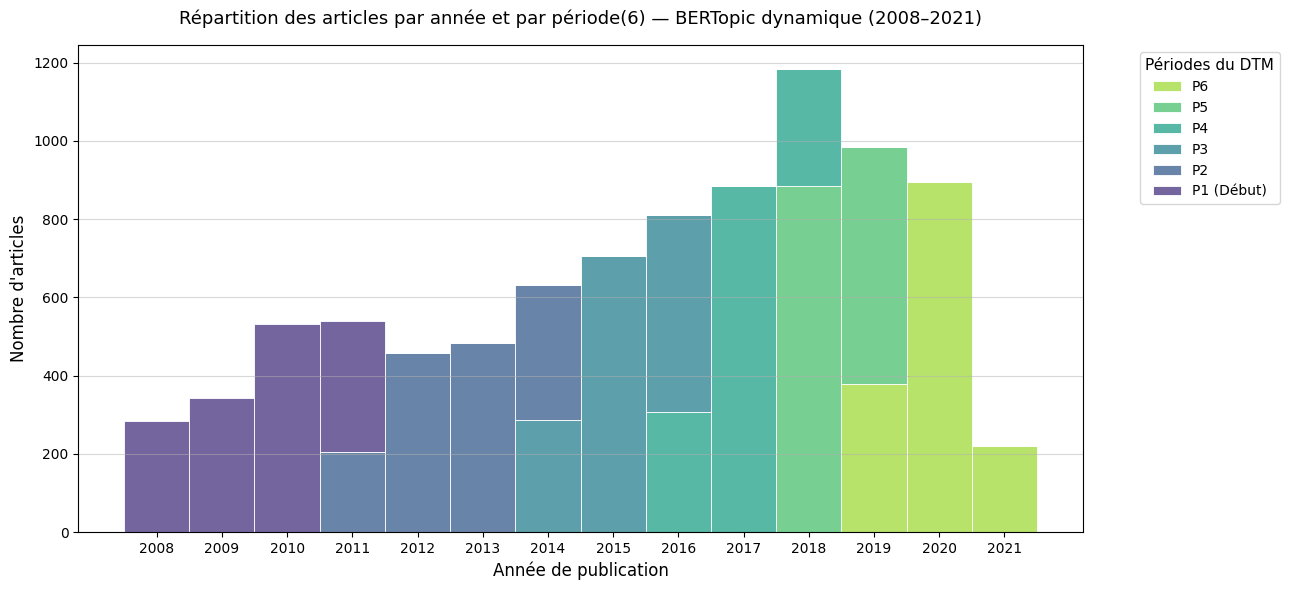

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# =========================================================
# PREPARATION — mapping année → période BERTopic
# =========================================================

# Reconstruit le mapping depuis df_select_trie2 déjà trié et découpé
# (df_select_trie2 doit contenir la colonne "periode" et "pub_date")

df_plot = df_select_trie2[["pub_date", "periode"]].copy()
df_plot["annee"] = df_plot["pub_date"].dt.year

# Labels lisibles des périodes (dans l'ordre croissant)
periode_labels = {
    0: "2008–2011",
    1: "2011–2014",
    2: "2014–2016",
    3: "2016–2018",
    4: "2018–2019",
    5: "2019–2021"
}

df_plot["periode_label"] = df_plot["periode"].map(periode_labels)

# Ordre des périodes pour la légende et les couleurs
ordre_periodes = list(periode_labels.values())

# =========================================================
# PLOT
# =========================================================

palette = sns.color_palette("viridis", n_colors=6)

plt.figure(figsize=(13, 6))

sns.histplot(
    data=df_plot,
    x="annee",
    hue="periode_label",
    hue_order=ordre_periodes,
    multiple="stack",
    palette=palette,
    discrete=True,
    edgecolor="white",
    linewidth=0.6
)

# Axes
plt.xticks(range(2008, 2022), fontsize=10)
plt.yticks(fontsize=10)
plt.xlabel("Année de publication", fontsize=12)
plt.ylabel("Nombre d'articles", fontsize=12)
plt.title(
    "Répartition des articles par année et par période(6) — BERTopic dynamique (2008–2021)",
    fontsize=13, pad=15
)

# Légende
plt.legend(
    title="Périodes du DTM",
    labels=[f"P6",f"P5",f"P4", f"P3", f"P2", f"P1 (Début)"],
    bbox_to_anchor=(1.05, 1), 
    loc='upper left',
    fontsize=10,
    title_fontsize=11
)


plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

In [65]:
import numpy as np

# Recharger topics_final depuis le fichier sauvegardé
topics_final = np.load("topics_final.npy", allow_pickle=True).tolist()
print(f"✅ topics_final rechargé : {len(topics_final)} documents")
print(f"Exemple : {topics_final[:5]}")

✅ topics_final rechargé : 8958 documents
Exemple : [0, 8, 6, np.int64(9), 0]


Fonctions chargées : extraire_lda, extraire_dtm, extraire_bert, extraire_bert_dynamique, tracer_graphique
Graphique sauvegardé : causes_vs_consequences.png


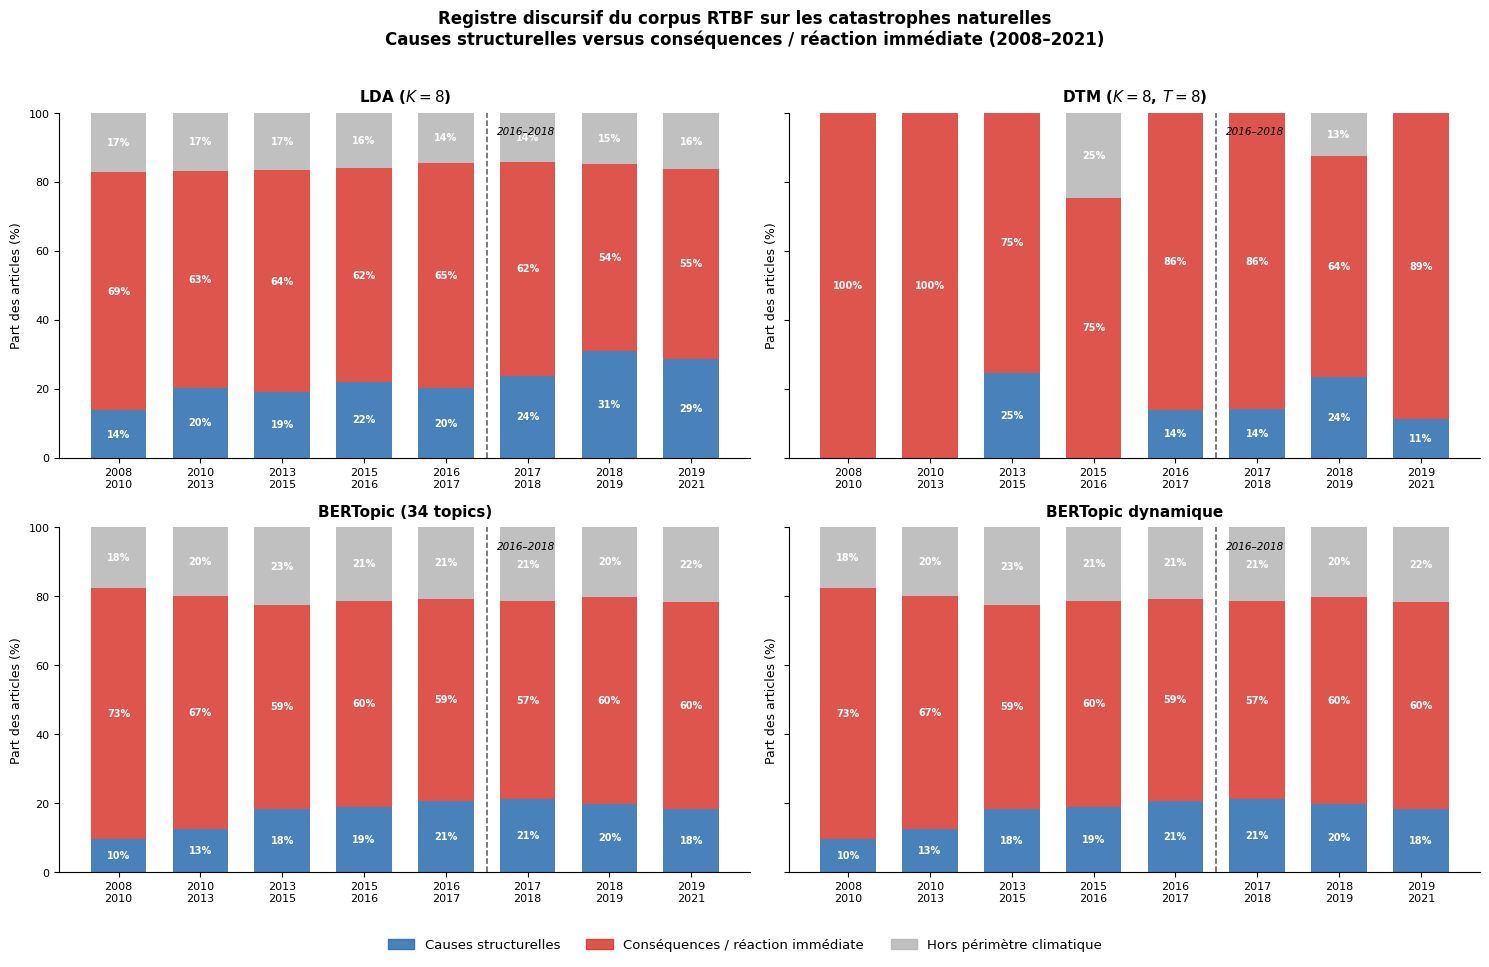

In [68]:
import numpy as np
import pickle

# ── 1. Recharger topics_final ───────────────────────────────
topics_final = np.load("topics_final.npy", allow_pickle=True).tolist()

# ── 2. Recharger df_lda et df_dtm depuis le notebook LDA ───
d = pickle.load(open("df_causes.pkl", "rb"))
df_lda = d["lda"]
df_dtm = d["dtm"]

# ── 3. Charger le script de fonctions ───────────────────────
exec(open("causes_vs_consequences_final.py").read())

# ── 4. Extraction ────────────────────────────────────────────
df_bert  = extraire_bert(topics_final, df_select_trie2, BERT_ASSIGNATION)
df_bertd = extraire_bert_dynamique(topics_over_time, BERT_ASSIGNATION)

# ── 5. Tracé ─────────────────────────────────────────────────
tracer_graphique(
    dict_modeles={
        "LDA ($K=8$)":          df_lda,
        "DTM ($K=8$, $T=8$)":   df_dtm,
        "BERTopic (34 topics)": df_bert,
        "BERTopic dynamique":   df_bertd,
    },
    chemin_sortie="causes_vs_consequences.png"
)


In [69]:
print(df_select_trie2["category"].value_counts().head(20))

category
MONDE             3711
SOCIETE           2271
REGIONS           1724
BELGIQUE           571
ECONOMIE           326
MEDIAS             124
ETCETERA           116
CHRONIQUES          67
AU QUOTIDIEN        19
OPINIONS            11
INSIDE               4
7 A LA UNE           4
TRANSVERSALES        2
GENERAL              1
L INDISCRET          1
LE 15 MINUTES        1
JEUDI EN PRIME       1
Name: count, dtype: int64


✅ Graphique sauvegardé


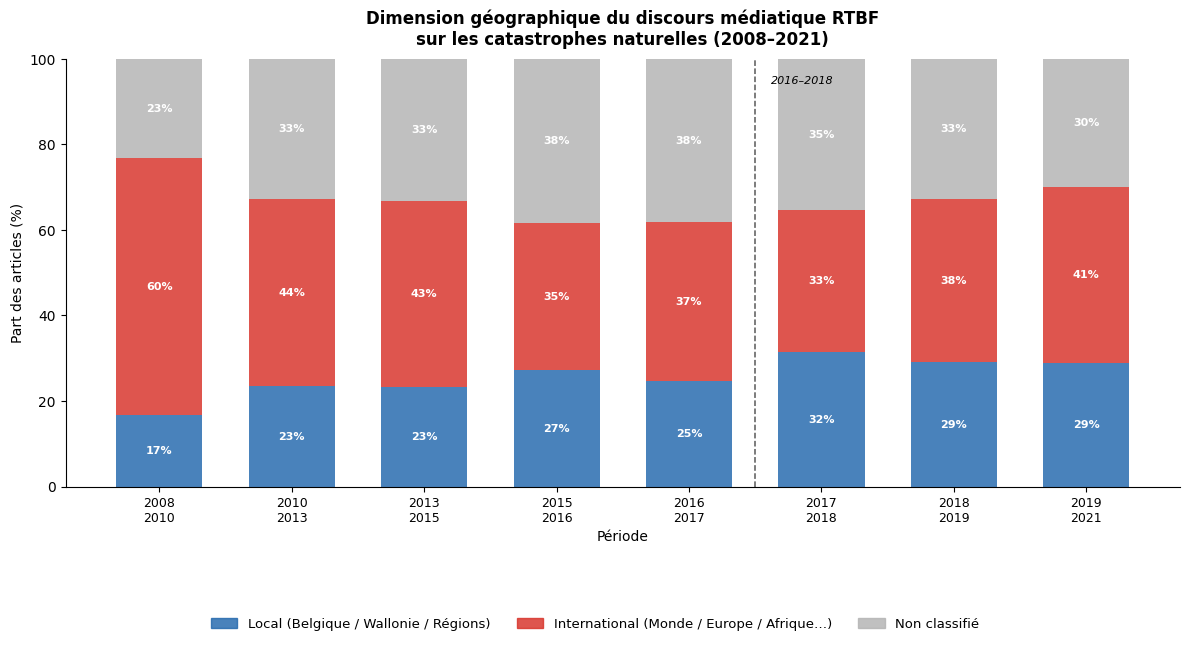

In [71]:
# ─────────────────────────────────────────────────────────────
# Graphique : dimension locale vs internationale par période
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Assignation géographique ──────────────────────────────
# Basée sur la colonne 'category' de df_select_trie2

GEO_LOCAL = {
    "BELGIQUE", "REGIONS", "RÉGION", "RÉGIONS",
    "BRUXELLES", "WALLONIE", "FLANDRE", "LOCAL"
}

GEO_INTER = {
    "MONDE", "INTERNATIONAL", "EUROPE", "AFRIQUE",
    "ASIE", "AMERIQUE", "OCÉANIE", "MOYEN-ORIENT"
}

def assigner_geo(category):
    if pd.isna(category):
        return "autre"
    cat = str(category).upper().strip()
    if any(loc in cat for loc in GEO_LOCAL):
        return "local"
    elif any(inter in cat for inter in GEO_INTER):
        return "international"
    else:
        return "autre"

# ── 2. Appliquer sur df_select_trie2 ─────────────────────────
df = df_select_trie2.copy()
df["geo"] = df["category"].apply(assigner_geo)

# ── 3. Calculer les proportions par période ───────────────────
PERIODES_LABELS = [
    "2008\n2010", "2010\n2013", "2013\n2015", "2015\n2016",
    "2016\n2017", "2017\n2018", "2018\n2019", "2019\n2021"
]

counts = (
    df.groupby(["periode", "geo"])
    .size()
    .unstack(fill_value=0)
)

# S'assurer que les colonnes existent
for col in ["local", "international", "autre"]:
    if col not in counts.columns:
        counts[col] = 0

# Pourcentage par période
pct = counts.div(counts.sum(axis=1), axis=0) * 100
pct.index = PERIODES_LABELS

# ── 4. Tracé ──────────────────────────────────────────────────
couleurs = {
    "local":          "#2166ac",   # bleu
    "international":  "#d73027",   # rouge
    "autre":          "#b2b2b2",   # gris
}
labels_legende = {
    "local":          "Local (Belgique / Wallonie / Régions)",
    "international":  "International (Monde / Europe / Afrique…)",
    "autre":          "Non classifié",
}
ordre = ["local", "international", "autre"]

fig, ax = plt.subplots(figsize=(12, 6))

x      = np.arange(len(pct))
bottom = np.zeros(len(pct))

for geo in ordre:
    vals = pct[geo].fillna(0).values
    ax.bar(x, vals, bottom=bottom,
           color=couleurs[geo], alpha=0.82, width=0.65)
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 6:
            ax.text(xi, b + v / 2, f"{v:.0f}%",
                    ha="center", va="center",
                    fontsize=8, color="white", fontweight="bold")
    bottom += vals

# Repère inflexion 2016-2018
ax.axvline(x=4.5, color="black", linestyle="--",
           linewidth=1.1, alpha=0.65)
ax.text(4.62, 96, "2016–2018",
        fontsize=8, color="black", va="top", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(pct.index, fontsize=9)
ax.set_ylim(0, 100)
ax.set_ylabel("Part des articles (%)", fontsize=10)
ax.set_xlabel("Période", fontsize=10)
ax.set_title(
    "Dimension géographique du discours médiatique RTBF\n"
    "sur les catastrophes naturelles (2008–2021)",
    fontsize=12, fontweight="bold", pad=10
)
ax.spines[["top", "right"]].set_visible(False)

# ── Légende tout en bas, sur toute la largeur ────────────────
patches = [
    mpatches.Patch(color=couleurs[g], alpha=0.82,
                   label=labels_legende[g])
    for g in ordre
]
fig.legend(
    handles=patches,
    loc="lower center",
    ncol=3,                    # une colonne par catégorie → s'étend sur toute la largeur
    fontsize=9.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.08)  # descend sous l'axe
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)   # laisse de la place pour la légende en bas

plt.savefig("geo_local_vs_international.png",
            bbox_inches="tight", dpi=300)
plt.savefig("geo_local_vs_international.pdf",
            bbox_inches="tight", dpi=300)
print("✅ Graphique sauvegardé")
plt.show()

✅ Figure sauvegardée


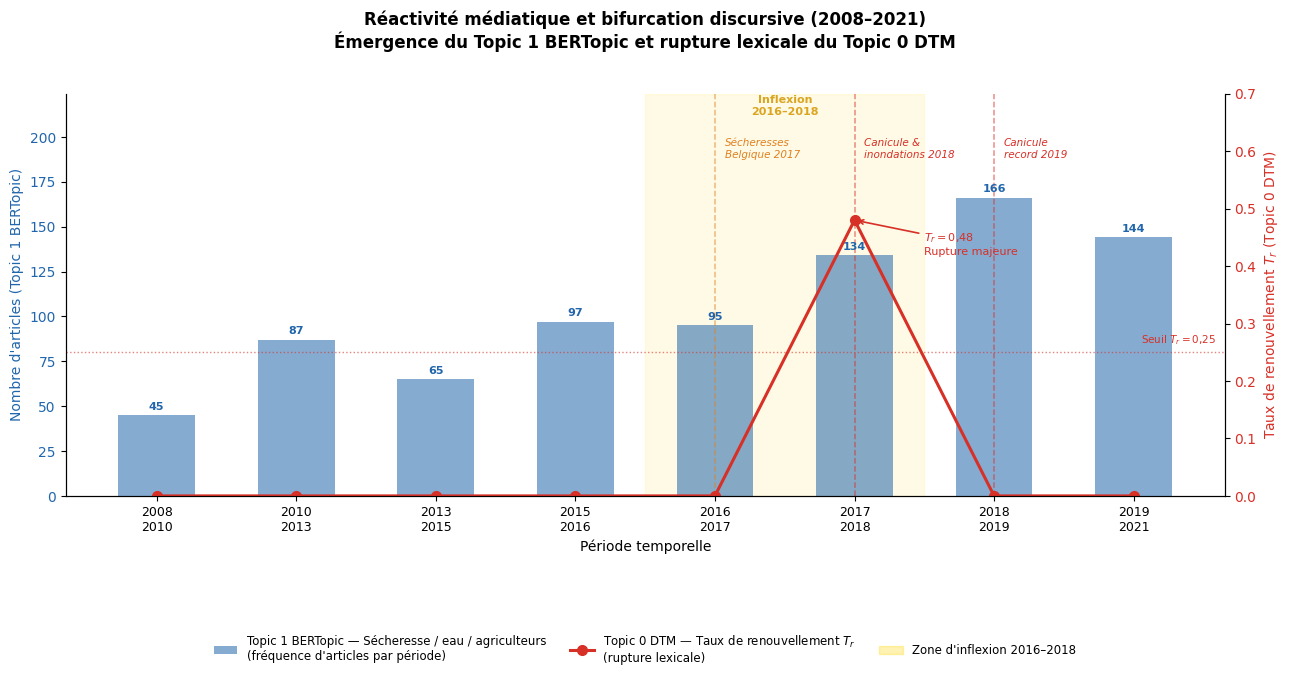

In [73]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
# 1. DONNÉES — Topic 1 BERTopic (fréquence par période)
# ─────────────────────────────────────────────────────────────
# Extraire depuis topics_over_time
topic1_bert = (
    topics_over_time[topics_over_time["Topic"] == 1]
    [["Timestamp", "Frequency"]]
    .set_index("Timestamp")
    .reindex([
        "2008_2010", "2010_2013", "2013_2015", "2015_2016",
        "2016_2017", "2017_2018", "2018_2019", "2019_2021"
    ])
    .fillna(0)
)

# ─────────────────────────────────────────────────────────────
# 2. DONNÉES — Topic 0 DTM (taux de renouvellement Tr)
# Valeurs issues du tableau tbl-Tr de votre mémoire
# ─────────────────────────────────────────────────────────────
# Tr pour Topic 0 : une seule transition significative à T4→T5
# Les autres périodes ont Tr < 0.25 (non retenues dans tbl-Tr)
# On les met à 0 pour signifier l'absence de rupture détectée

tr_topic0 = pd.Series({
    "2008_2010": 0.00,
    "2010_2013": 0.00,
    "2013_2015": 0.00,
    "2015_2016": 0.00,
    "2016_2017": 0.00,   # transition T4→T5 : rupture ici
    "2017_2018": 0.48,   # Tr = 0.48 — rupture majeure
    "2018_2019": 0.00,
    "2019_2021": 0.00,
})

# ─────────────────────────────────────────────────────────────
# 3. ÉVÉNEMENTS CLIMATIQUES EXTRÊMES MAJEURS
# (repères verticaux avec annotation)
# ─────────────────────────────────────────────────────────────
evenements = [
    {"periode": "2016_2017", "label": "Sécheresses\nBelgique 2017",   "couleur": "#e08020"},
    {"periode": "2017_2018", "label": "Canicule &\ninondations 2018", "couleur": "#d73027"},
    {"periode": "2018_2019", "label": "Canicule\nrecord 2019",        "couleur": "#d73027"},
]

# ─────────────────────────────────────────────────────────────
# 4. PARAMÈTRES COMMUNS
# ─────────────────────────────────────────────────────────────
PERIODES = [
    "2008_2010", "2010_2013", "2013_2015", "2015_2016",
    "2016_2017", "2017_2018", "2018_2019", "2019_2021"
]
PERIODES_LABELS = [p.replace("_", "\n") for p in PERIODES]
x = np.arange(len(PERIODES))
periode_to_x = {p: i for i, p in enumerate(PERIODES)}

# ─────────────────────────────────────────────────────────────
# 5. FIGURE — double axe Y
# ─────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()   # second axe Y à droite

# ── Axe gauche : fréquence Topic 1 BERTopic (barres) ─────────
freq_vals = topic1_bert["Frequency"].values
bars = ax1.bar(
    x, freq_vals,
    color="#2166ac", alpha=0.55, width=0.55,
    label="Topic 1 BERTopic — Sécheresse / eau / agriculteurs\n(fréquence d'articles par période)"
)
# Étiquettes sur les barres
for xi, v in enumerate(freq_vals):
    if v > 0:
        ax1.text(xi, v + 2, f"{int(v)}",
                 ha="center", va="bottom",
                 fontsize=8, color="#2166ac", fontweight="bold")

ax1.set_ylabel("Nombre d'articles (Topic 1 BERTopic)",
               fontsize=10, color="#2166ac")
ax1.tick_params(axis="y", labelcolor="#2166ac")
ax1.set_ylim(0, max(freq_vals) * 1.35)

# ── Axe droit : Tr Topic 0 DTM (ligne) ───────────────────────
tr_vals = [tr_topic0[p] for p in PERIODES]
ax2.plot(
    x, tr_vals,
    color="#d73027", linewidth=2.2,
    marker="o", markersize=7,
    label="Topic 0 DTM — Taux de renouvellement $T_r$\n(rupture lexicale)"
)
# Annotation de la rupture majeure
idx_rupture = PERIODES.index("2017_2018")
ax2.annotate(
    "$T_r = 0{,}48$\nRupture majeure",
    xy=(idx_rupture, 0.48),
    xytext=(idx_rupture + 0.5, 0.42),
    fontsize=8, color="#d73027",
    arrowprops=dict(arrowstyle="->", color="#d73027", lw=1.2)
)
# Seuil de rupture à 0.25
ax2.axhline(y=0.25, color="#d73027", linestyle=":",
            linewidth=1.0, alpha=0.6)
ax2.text(7.05, 0.26, "Seuil $T_r = 0{,}25$",
         fontsize=7.5, color="#d73027", va="bottom")

ax2.set_ylabel("Taux de renouvellement $T_r$ (Topic 0 DTM)",
               fontsize=10, color="#d73027")
ax2.tick_params(axis="y", labelcolor="#d73027")
ax2.set_ylim(0, 0.70)

# ── Repères verticaux : événements climatiques ────────────────
for ev in evenements:
    xi = periode_to_x[ev["periode"]]
    ax1.axvline(x=xi, color=ev["couleur"],
                linestyle="--", linewidth=1.1, alpha=0.55)
    ax1.text(xi + 0.07, max(freq_vals) * 1.20,
             ev["label"],
             fontsize=7.5, color=ev["couleur"],
             va="top", style="italic")

# ── Zone grisée : période d'inflexion 2016-2018 ───────────────
ax1.axvspan(3.5, 5.5, color="gold", alpha=0.10, zorder=0)
ax1.text(4.5, max(freq_vals) * 1.28,
         "Inflexion\n2016–2018",
         ha="center", fontsize=8,
         color="goldenrod", fontweight="bold")

# ── Axes communs ──────────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(PERIODES_LABELS, fontsize=9)
ax1.set_xlabel("Période temporelle", fontsize=10)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

# ── Titre ─────────────────────────────────────────────────────
fig.suptitle(
    "Réactivité médiatique et bifurcation discursive (2008–2021)\n"
    "Émergence du Topic 1 BERTopic et rupture lexicale du Topic 0 DTM",
    fontsize=12, fontweight="bold", y=1.01
)

# ── Légende commune en bas ────────────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Ajouter patch pour la zone grisée
zone_patch = mpatches.Patch(
    color="gold", alpha=0.3,
    label="Zone d'inflexion 2016–2018"
)

fig.legend(
    handles=lines1 + lines2 + [zone_patch],
    loc="lower center",
    ncol=3,
    fontsize=8.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.10)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.20)

plt.savefig("bifurcation_2016_2018.png",
            bbox_inches="tight", dpi=300)
plt.savefig("bifurcation_2016_2018.pdf",
            bbox_inches="tight", dpi=300)
print("✅ Figure sauvegardée")
plt.show()

'# ============================================\n# 0. IMPORTS — ajouter KMeans\n# ============================================\nimport optuna\nimport nltk\nimport string\nimport numpy as np\nfrom sklearn.feature_extraction.text import CountVectorizer\nfrom sklearn.cluster import KMeans\nfrom gensim.models.coherencemodel import CoherenceModel\nfrom gensim.corpora.dictionary import Dictionary\nfrom optuna.samplers import TPESampler\nfrom optuna.pruners import MedianPruner\nfrom collections import Counter\n\nnltk.download(\'stopwords\', quiet=True)\nfrom nltk.corpus import stopwords\n\n# ============================================\n# STOPWORDS — identique\n# ============================================\nfrench_stops  = set(stopwords.words(\'french\'))\ncustom_stops  = { ... }  # identique à avant\nFRENCH_STOPWORDS = list(french_stops | custom_stops | stop_words_fr)\n\n# ============================================\n# 2. FONCTION OBJECTIF — KMeans\n# ======================================